# Import the necessary packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import pathlib 
import os
# import scimap as sm
from utils.delaunay_graph import delaunay_adata_internal, delaunay_adata
from utils.cluster_stability import cluster_stability_calculate
from utils.celltype_enrichment_niche import nhood_enrichment
import anndata as ad

# Paths

In [2]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"

# Color palette

In [3]:
myeloid_palette = {
    "MDSCs": "#332288",
    "M2 macrophages": "#66A61E",
    "M1 macrophages": "#00557F",
    "M1/M2 macrophages": "#BBCCEE",
    "DCs": "#E69F00",
    "Granulocytes": "#B85AA6",
    "Mast cells": "#8E006A",
}
lymphoid_palette = {
    "CD8+ T cells": "#B2182B",
    "CD4+ T cells": "#EF8A62",
    "Treg T cells": "#FFCCCC",
    "NK cells": "#0096FF",
    "B cells": "#E6C84F",
    "PCs": "#F4E58A",
}
non_immune_palette = {
    "Actin+ cells": "#B39DDB",
    "Endothelial cells": "#00BFC4",
    "Lymphatic endothelial cells": "#1F78B4",
    "Epithelial cells": "#C9B29B",
}
other_palette = {
    "Tumor cells": "#44AA99",
    "NFC": "#DDDDDD",
}
full_palette = {
    **myeloid_palette,
    **lymphoid_palette,
    **non_immune_palette,
    **other_palette,
}

# Loading the required data

In [67]:
adata = sc.read_h5ad(os.path.join(data_dir, "adata.h5ad"))

# Creating delaunay graphs for the ROIs

In [68]:
adata = delaunay_adata(adata, 
                       coords_key="spatial", 
                       phenotype="cell_category", 
                       image_id="patient_exp", 
                       label="spatial_count_delaunay")

## Get the confusion matrix of the neighbors

In [69]:
adata.uns["spatial_prop_delaunay"] = adata.uns["spatial_count_delaunay"].div(adata.uns["spatial_count_delaunay"].sum(axis=1), axis=0)

In [70]:
adata.uns["spatial_prop_delaunay"]

neighbour_phenotype,Actin+ cells,B cells,CD4+ T cells,CD8+ T cells,DCs,Endothelial cells,Granulocytes,Lymphatic endothelial cells,M1 macrophages,M1/M2 macrophages,M2 macrophages,MDSCs,Mast cells,NFC,NK cells,PCs,Treg T cells,Tumor cells,Epithelial cells
378930,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0
66114,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0
66113,0.111111,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.222222,0.0,0.0,0.0,0.666667,0.0
66112,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0
66111,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.142857,0.285714,0.000000,0.000000,0.0,0.142857,0.0,0.0,0.0,0.428571,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420571,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.400000,0.0,0.0,0.0,0.600000,0.0
420572,0.000000,0.0,0.4,0.6,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
420573,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.400000,0.0,0.0,0.0,0.600000,0.0
420564,0.000000,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0


In [ ]:
best_k, best_score, results_df = cluster_stability_calculate(
    adata,
    uns_key="spatial_prop_delaunay",
    k_min=8,
    k_max=18,
    n_repeats=10,        
    sample_size=50000,      
    random_state=196979
)

k=8 | mean ARI=0.9608
k=9 | mean ARI=0.9175
k=10 | mean ARI=0.9442
k=11 | mean ARI=0.9646
k=12 | mean ARI=0.9654
k=13 | mean ARI=0.8720
k=14 | mean ARI=0.7272
k=15 | mean ARI=0.8711
k=16 | mean ARI=0.9021
k=17 | mean ARI=0.8265
k=18 | mean ARI=0.8638


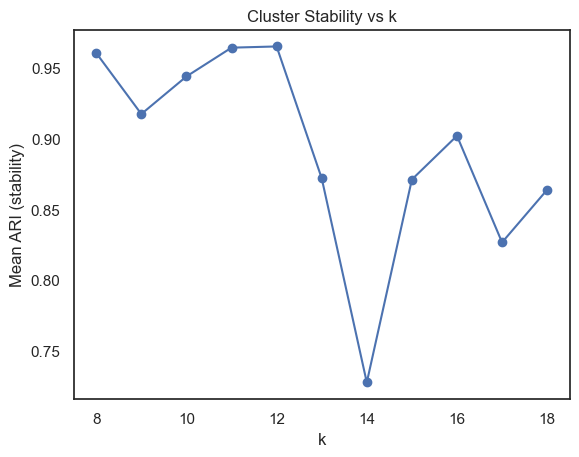

In [72]:
#showcase cluster stability analysis results
plt.figure()
plt.plot(results_df.index, results_df["mean_ARI"], marker="o")
plt.xlabel("k")
plt.ylabel("Mean ARI (stability)")
plt.title("Cluster Stability vs k")
plt.show()

In [73]:
#save the results of cluster stability analysis
results_df.to_csv(os.path.join(data_dir, "cluster_stability_results.csv"), index=True)

## k = 12

In [74]:
adata = sm.tl.spatial_cluster(adata, 
                              df_name='spatial_prop_delaunay', 
                              method='kmeans', 
                              k=12, 
                              label='neigh_kmeans_count', 
                              random_state=196979)

Kmeans clustering


In [75]:
sm.pl.stacked_barplot(adata, 
                      x_axis='neigh_kmeans_count', 
                      y_axis='cell_category', 
                      plot_tool='plotly', 
                      color_discrete_map = full_palette)

In [76]:
#mix clustters 4 and 9 since they are similar in composition and define the clusters as follows:
cluster_to_name = {
    0: "Lymphatic_immune",
    1: "Tumor_bulk",
    2: "Tumor_NFC",
    3: "Stromal_fibroblasts",
    4: "Myeloid_granulocytic",
    5: "Epithelial_adjacent",
    6: "Vascular/Endothelial",
    7: "Lymphoid_B",
    8: "Lymphoid_enriched",
    9: "Tumor_myeloid",
    10: "Lymphoid_T",
    11:"Stromal_NFC"
}
#make neigh_kmeans integers first
adata.obs["neigh_kmeans_count"] = adata.obs["neigh_kmeans_count"].astype(int)
adata.obs["neighborhood"] = adata.obs["neigh_kmeans_count"].map(cluster_to_name)

In [77]:
nhood_enrichment(
    adata,
    group_key="cell_category",
    label_key="neighborhood",
    log=True,
    pvalues=True, 
)

100%|██████████| 200/200 [00:11<00:00, 17.08it/s]


In [78]:
adata.uns.keys()

odict_keys(['spatial_count_delaunay', 'spatial_prop_delaunay', 'neighborhood_cell_category_enrichment'])

In [79]:
enr = adata.uns["neighborhood_cell_category_enrichment"]["enrichment"]
pvalues = adata.uns["neighborhood_cell_category_enrichment"]["pvalue"]

## Save the enrichment and the pvalues

In [80]:
enr.to_csv(os.path.join(data_dir, "neighborhood_cell_category_enrichment.csv"), index=True)
pvalues.to_csv(os.path.join(data_dir, "neighborhood_cell_category_enrichment_pvalues.csv"), index=True)

# Finally save the anndata with the neighborhoods

In [81]:
#save anndata
adata.write_h5ad(os.path.join(data_dir, "adata_with_neighborhoods.h5ad"))

## save the niches as niches_df for R

In [82]:
niches_df = adata.obs[["patient_ID", "patient_exp", "cell_category", "Cell Center X", "Cell Center Y", "survival_time_months", "neighborhood"]].copy()
niches_df.to_csv(os.path.join(data_dir, "niches_df.csv"), index=False)

In [4]:
adata_neighborhoods = sc.read_h5ad(os.path.join(data_dir, "adata_with_neighborhoods.h5ad"))

In [5]:
#keep in adata run == 141 and 145
adata_neighborhoods_subset = adata_neighborhoods[adata_neighborhoods.obs["run"].isin([141, 145])].copy()
#markers vector
markers = adata_neighborhoods_subset.var_names
#keep markers where not all values are NA
markers = [
    marker for marker in markers
    if not np.isnan(adata_neighborhoods_subset[:, marker].X.toarray()).any()
]

In [6]:
adata_neighborhoods_subset = adata_neighborhoods_subset[:, markers].copy()

adata_neighborhoods_subset.X = np.arcsinh(adata_neighborhoods_subset.X)

In [50]:
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_4"

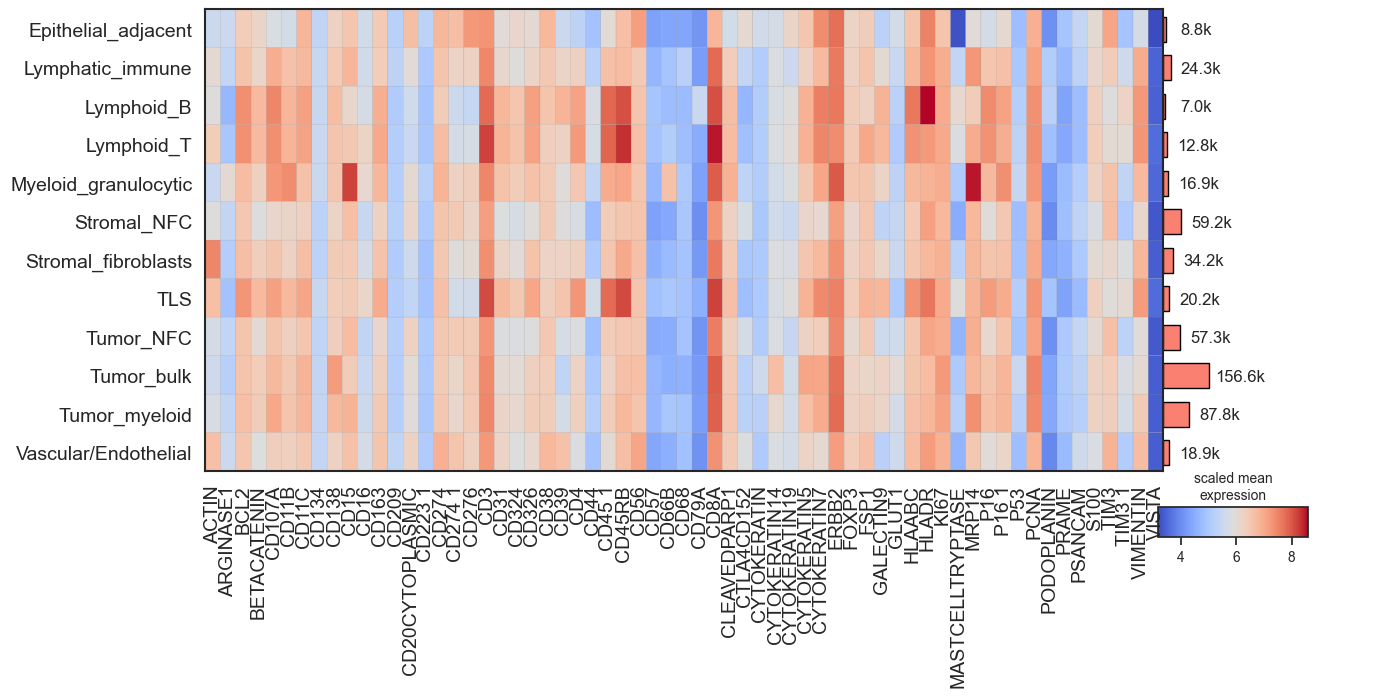

In [36]:
plot = sc.pl.matrixplot(adata_neighborhoods_subset, markers, groupby='neighborhood', 
                            cmap='coolwarm', 
                            use_raw=False, 
                            figsize=(15, 6), 
                            return_fig=True)
plot.add_totals()
axes = plot.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14) 
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 12, current_pos[1]+4))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax.set_position([0.76, 0, 0.1, 0.05])
fig = axes['mainplot_ax'].figure
# fig.savefig(os.path.join(results_dir, 'stacked_violin.png'), 
#             dpi=300, 
#             bbox_inches='tight')

## EXPERIMENTING

In [6]:
adata = sc.read_h5ad(os.path.join(data_dir, "adata_with_neighborhoods.h5ad"))

In [7]:
#markers to keep 
adata_141 = adata[adata.obs["run"] == 141].copy()
#get the var_names that have no NA values
markers_141 = [
    marker for marker in adata_141.var_names
    if not np.isnan(adata_141[:, marker].X.toarray()).any()
]
#same for 145
adata_145 = adata[adata.obs["run"] == 145].copy()
markers_145 = [
    marker for marker in adata_145.var_names
    if not np.isnan(adata_145[:, marker].X.toarray()).any()
]
#take the intersection of the two marker lists
markers = list(set(markers_141) & set(markers_145))


In [8]:
#make anndata_unified
adata_unified = adata[:, markers].copy()
#arcsinh-transform your data
adata_unified.layers["arcsinh"] = np.arcsinh(adata_unified.X)


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_20537/407716522.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["neighborhood", "patient_exp", "cell_category"])["KI67"]
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_20537/407716522.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_df.groupby("neighborhood")["KI67"]
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_20537/407716522.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabel

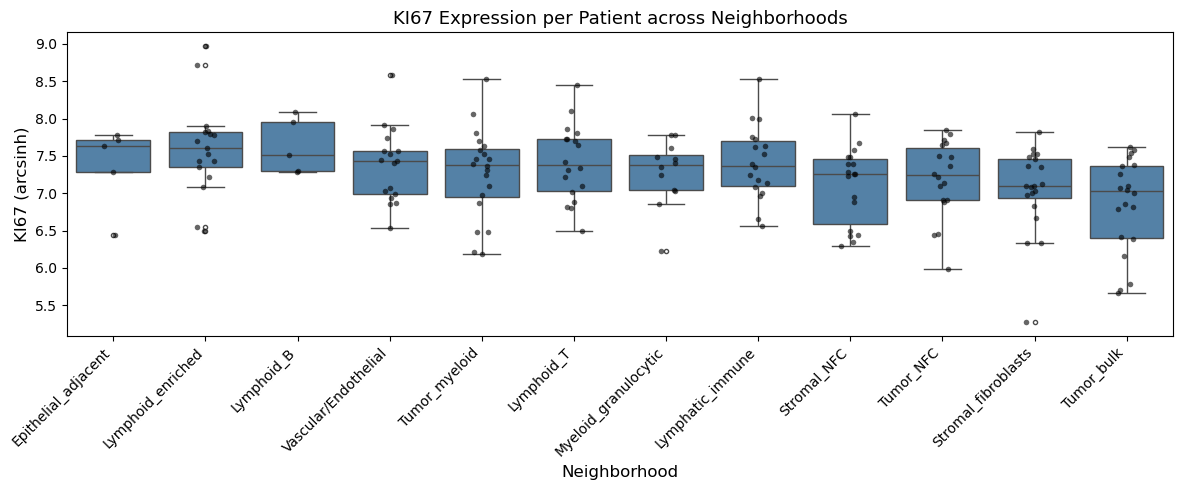

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract KI67 arcsinh values
ki67_idx = list(adata_unified.var_names).index("HLADR")
ki67_values = adata_unified.layers["arcsinh"][:, ki67_idx]

# Build a dataframe with per-cell values + metadata
df = pd.DataFrame({
    "KI67": np.array(ki67_values).flatten(),
    "neighborhood": adata_unified.obs["neighborhood"].values,
    "patient_exp": adata_unified.obs["patient_exp"].values,
    "cell_category": adata_unified.obs["cell_category"].values
})

#filter df for only CD8+ T cells
df = df[df["cell_category"] == "CD8+ T cells"]

# Aggregate to patient level: median KI67 per patient per neighborhood
patient_df = (
    df.groupby(["neighborhood", "patient_exp", "cell_category"])["KI67"]
    .median()
    .reset_index()
)

# Compute neighborhood-level median (of patient medians) for ordering
neighborhood_order = (
    patient_df.groupby("neighborhood")["KI67"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=patient_df,
    x="neighborhood",
    y="KI67",
    order=neighborhood_order,
    color="steelblue",
    fliersize=3,
    ax=ax,
)
sns.stripplot(
    data=patient_df,
    x="neighborhood",
    y="KI67",
    order=neighborhood_order,
    color="black",
    alpha=0.6,
    size=4,
    jitter=True,
    ax=ax,
)

ax.set_xlabel("Neighborhood", fontsize=12)
ax.set_ylabel("KI67 (arcsinh)", fontsize=12)
ax.set_title("KI67 Expression per Patient across Neighborhoods", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84848/1958703186.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["cell_category", "patient_exp"])["GLUT1"]
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84848/1958703186.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_df.groupby("cell_category")["GLUT1"]
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_84848/1958703186.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotat

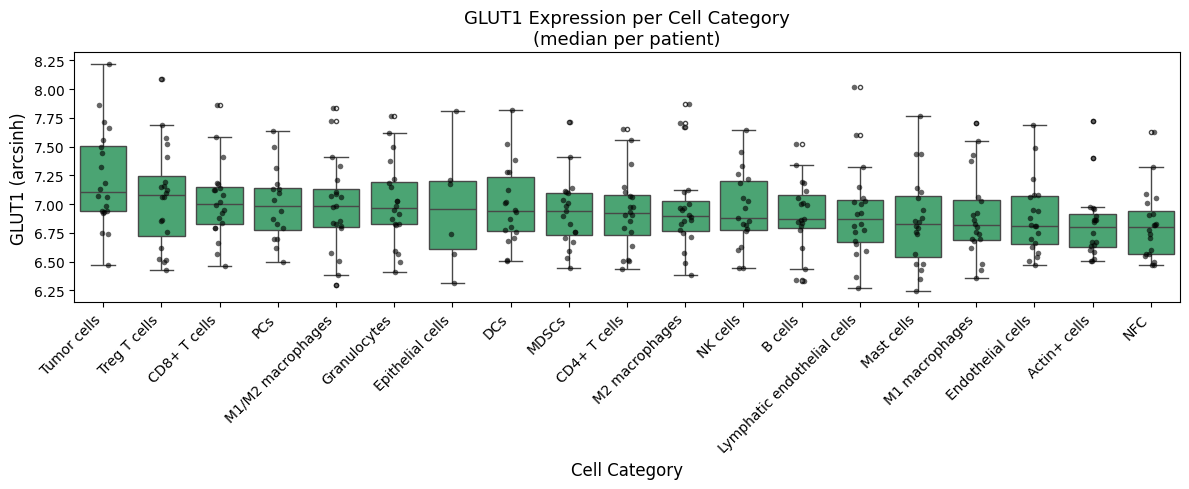

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract GLUT1 arcsinh values
glut1_idx = list(adata_unified.var_names).index("KI67")
glut1_values = np.array(adata_unified.layers["arcsinh"][:, glut1_idx]).flatten()

# Build dataframe
df = pd.DataFrame({
    "GLUT1": glut1_values,
    "cell_category": adata_unified.obs["cell_category"].values,
    "patient_exp": adata_unified.obs["patient_exp"].values,
})

# Aggregate to patient level per cell category
patient_df = (
    df.groupby(["cell_category", "patient_exp"])["GLUT1"]
    .median()
    .reset_index()
)

# Sort cell categories by median of patient medians (descending)
category_order = (
    patient_df.groupby("cell_category")["GLUT1"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=patient_df,
    x="cell_category",
    y="GLUT1",
    order=category_order,
    color="mediumseagreen",
    fliersize=3,
    ax=ax,
)
sns.stripplot(
    data=patient_df,
    x="cell_category",
    y="GLUT1",
    order=category_order,
    color="black",
    alpha=0.6,
    size=4,
    jitter=True,
    ax=ax,
)

ax.set_xlabel("Cell Category", fontsize=12)
ax.set_ylabel("GLUT1 (arcsinh)", fontsize=12)
ax.set_title("GLUT1 Expression per Cell Category\n(median per patient)", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/2670939936.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/2670939936.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/2670939936.py:67: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/2670939936.py:67: FutureWa

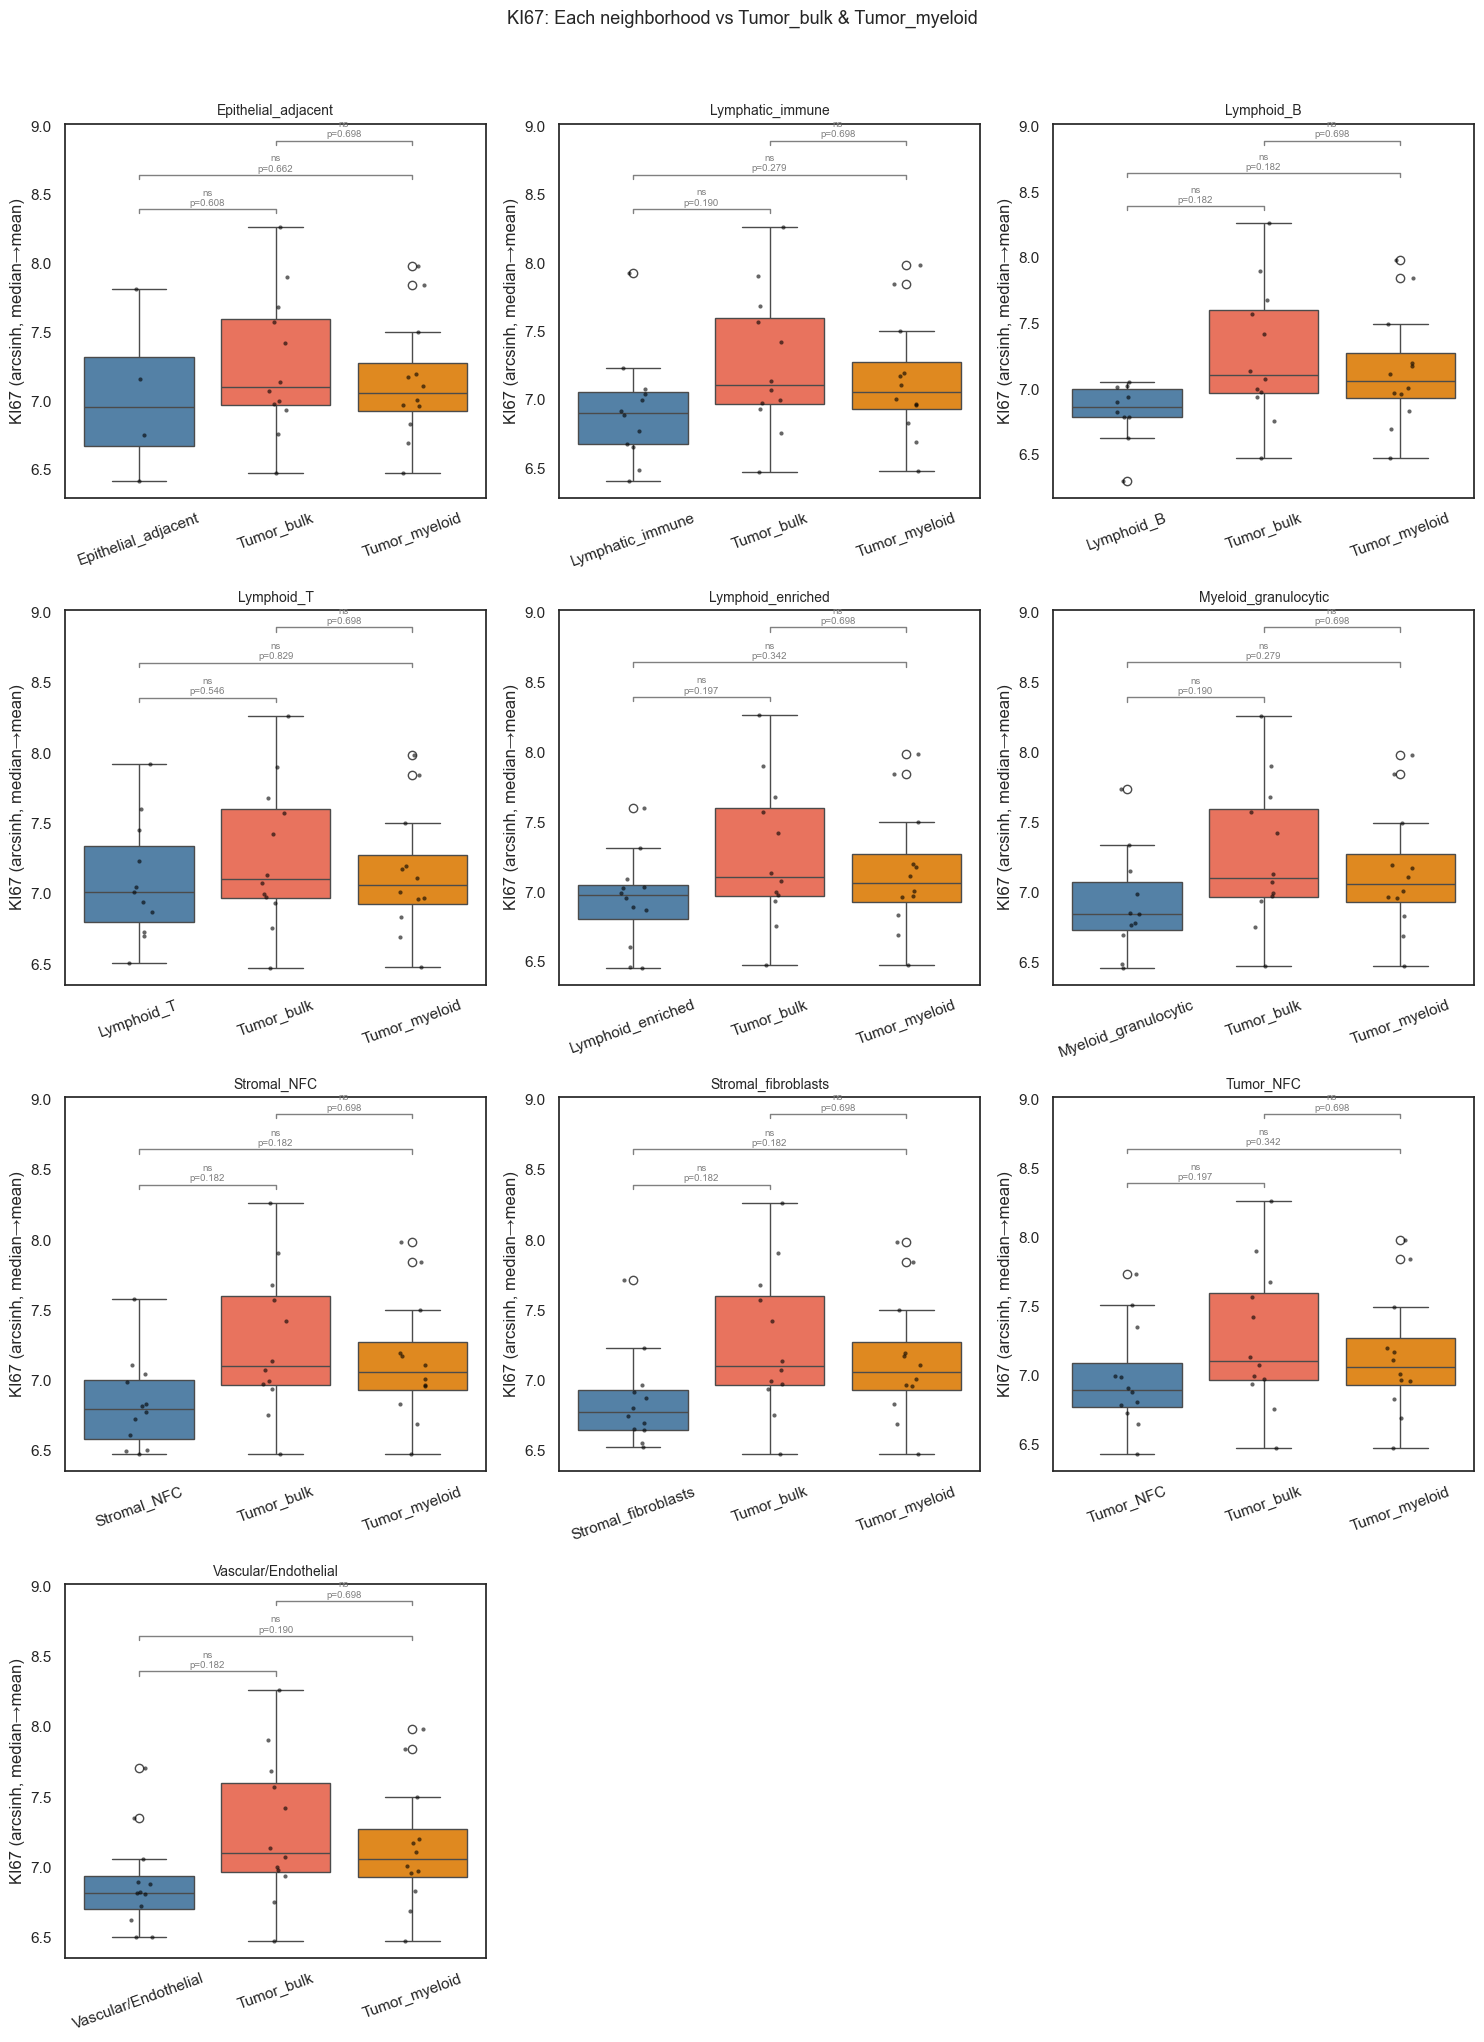

In [32]:
# --- Build aggregated df for KI67 only ---
ki67_idx = adata_unified.var_names.get_loc("KI67")

df = adata_unified.obs[["patient_ID", "patient_exp", "neighborhood"]].copy()
df["KI67"] = adata_unified.layers["arcsinh"][:, ki67_idx]

# Step 1: median per ROI
df_roi = df.groupby(["patient_ID", "patient_exp", "neighborhood"])["KI67"].median().reset_index()

# Step 2: mean across ROIs per patient
df_agg = df_roi.groupby(["patient_ID", "neighborhood"])["KI67"].mean().reset_index()

# --- Define comparisons ---
reference_neighborhoods = ["Tumor_bulk", "Tumor_myeloid"]
all_neighborhoods = df_agg["neighborhood"].unique().tolist()
other_neighborhoods = [n for n in all_neighborhoods if n not in reference_neighborhoods]

pairs = [(ref, other) for ref in reference_neighborhoods for other in other_neighborhoods]
pairs.append(("Tumor_bulk", "Tumor_myeloid"))

# --- Run Mann-Whitney U tests with FDR correction ---
results = []
for n1, n2 in pairs:
    g1 = df_agg[df_agg["neighborhood"] == n1]["KI67"].dropna()
    g2 = df_agg[df_agg["neighborhood"] == n2]["KI67"].dropna()
    if len(g1) < 3 or len(g2) < 3:
        continue
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    results.append({"n1": n1, "n2": n2, "p_value": p})

results_df = pd.DataFrame(results)
_, p_adj, _, _ = multipletests(results_df["p_value"], method="fdr_bh")
results_df["p_adj"] = p_adj
results_df["significant"] = results_df["p_adj"] < 0.05

# --- Helper functions ---
def get_pval(df, a, b):
    row = df[((df["n1"] == a) & (df["n2"] == b)) | ((df["n1"] == b) & (df["n2"] == a))]
    return row["p_adj"].values[0] if len(row) else np.nan

def pval_label(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

def draw_bracket(ax, x1, x2, y, p):
    label = pval_label(p)
    color = "black" if label != "ns" else "gray"
    ax.plot([x1, x1, x2, x2], [y, y + 0.03, y + 0.03, y], lw=1, color=color)
    ax.text((x1 + x2) / 2, y + 0.04, f"{label}\np={p:.3f}",
            ha="center", va="bottom", fontsize=7, color=color)

# --- Plot ---
ncols = 3
nrows = int(np.ceil(len(other_neighborhoods) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))
axes = axes.flatten()

for i, neighborhood in enumerate(other_neighborhoods):
    ax = axes[i]
    order = [neighborhood, "Tumor_bulk", "Tumor_myeloid"]
    plot_df = df_agg[df_agg["neighborhood"].isin(order)].copy()
    pal = {neighborhood: "steelblue", "Tumor_bulk": "tomato", "Tumor_myeloid": "darkorange"}

    sns.boxplot(data=plot_df, x="neighborhood", y="KI67", order=order, ax=ax, palette=pal)
    sns.stripplot(data=plot_df, x="neighborhood", y="KI67", order=order, ax=ax,
                  color="black", size=3, alpha=0.6)

    y_base = plot_df["KI67"].max() + 0.1
    bracket_gap = 0.25

    draw_bracket(ax, 0, 1, y_base, get_pval(results_df, neighborhood, "Tumor_bulk"))
    draw_bracket(ax, 0, 2, y_base + bracket_gap, get_pval(results_df, neighborhood, "Tumor_myeloid"))
    draw_bracket(ax, 1, 2, y_base + bracket_gap * 2, get_pval(results_df, "Tumor_bulk", "Tumor_myeloid"))

    ax.set_title(neighborhood, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("KI67 (arcsinh, median→mean)")
    ax.tick_params(axis="x", rotation=20)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("KI67: Each neighborhood vs Tumor_bulk & Tumor_myeloid", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
test = ["GLUT1", "KI67", "P53", "GALECTIN9"]

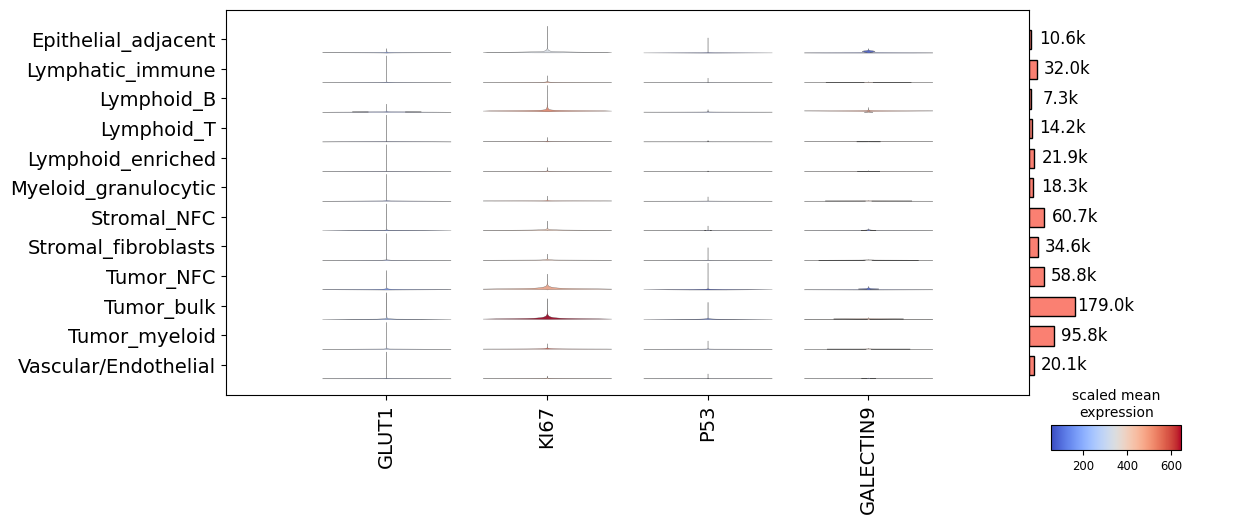

In [ ]:
plot = sc.pl.stacked_violin(adata_unified, test, groupby='neighborhood', cmap='coolwarm', use_raw=False, density_norm='area', figsize=(13, 5), return_fig=True)
plot.add_totals()
axes = plot.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14) 
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 12, current_pos[1]+4))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax.set_position([0.76, 0, 0.1, 0.05])
fig = axes['mainplot_ax'].figure
# fig.savefig(os.path.join("/Users/jawadalaaedeen/Desktop/", 'stacked_violin.pdf'), 
#             dpi=300, 
#             bbox_inches='tight')

cell_category  M2 macrophages     MDSCs  Granulocytes
patient_ID                                           
NUT_1                0.743151  0.253425      0.003425
NUT_2                0.216216  0.168168      0.615616
NUT_4                0.040446  0.330544      0.629010
NUT_5                0.317943  0.329486      0.352571
NUT_6                0.861239  0.000000      0.138761
NUT_7                0.624722  0.364143      0.011136
NUT_8                0.191304  0.356522      0.452174
NUT_9                0.109327  0.469421      0.421251
NUT_12               0.923077  0.060440      0.016484
NUT_13               0.826790  0.166282      0.006928
NUT_14               0.577236  0.317073      0.105691
NUT_15               0.057778  0.135556      0.806667
NUT_16               0.178746  0.563211      0.258044


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/2088085524.py:16: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



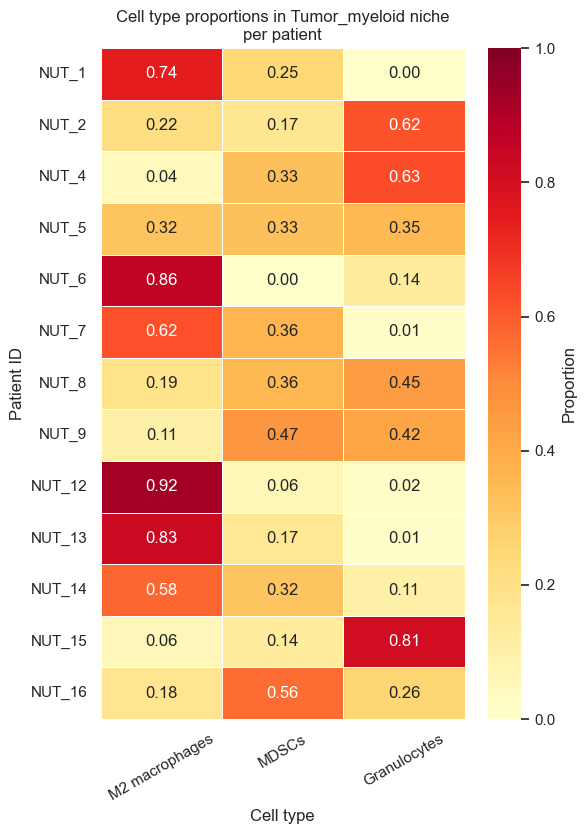

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Filter to Tumor_myeloid neighborhood ---
mask = adata_unified.obs["neighborhood"] == "Tumor_myeloid"
df = adata_unified.obs[mask][["patient_ID", "cell_category"]].copy()

# --- Filter to cell types of interest ---
cells_of_interest = ["M2 macrophages", "MDSCs", "Granulocytes"]
df = df[df["cell_category"].isin(cells_of_interest)]

# --- Compute proportions per patient ---
# Count each cell type per patient
counts = df.groupby(["patient_ID", "cell_category"]).size().unstack(fill_value=0)

# Normalize to proportions (row-wise)
proportions = counts.div(counts.sum(axis=1), axis=0)

# Ensure all cell types are present even if missing for some patients
for cell in cells_of_interest:
    if cell not in proportions.columns:
        proportions[cell] = 0.0
proportions = proportions[cells_of_interest]

print(proportions)

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(6, len(proportions) * 0.5 + 2))

sns.heatmap(
    proportions,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Proportion"}
)

ax.set_title("Cell type proportions in Tumor_myeloid niche\nper patient", fontsize=12)
ax.set_xlabel("Cell type")
ax.set_ylabel("Patient ID")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

In [49]:
cd15_per_celltype

cell_category
Actin+ cells                  NaN
B cells                       NaN
CD4+ T cells                  NaN
CD8+ T cells                  NaN
DCs                           NaN
Endothelial cells             NaN
Granulocytes                  NaN
Lymphatic endothelial cells   NaN
M1 macrophages                NaN
M1/M2 macrophages             NaN
M2 macrophages                NaN
MDSCs                         NaN
Mast cells                    NaN
NFC                           NaN
NK cells                      NaN
Treg T cells                  NaN
Tumor cells                   NaN
Name: CD15, dtype: float64

In [50]:
mask = adata_unified.obs["patient_ID"] == "NUT_7"
adata_sub = adata_unified[mask]

cd15_idx = adata_unified.var_names.get_loc("CD15")

# Check what we're getting
print("CD15 index:", cd15_idx)
print("Layer slice sample:", adata_sub.layers["arcsinh"][:5, cd15_idx])
print("Any NaN?", np.isnan(adata_sub.layers["arcsinh"][:, cd15_idx]).any())
print("All NaN?", np.isnan(adata_sub.layers["arcsinh"][:, cd15_idx]).all())
print("NUT_7 cell count:", mask.sum())
print("Unique cell_category in NUT_7:", adata_sub.obs["cell_category"].unique())

CD15 index: 56
Layer slice sample: [6.03994557 6.10922309 6.44790027 6.23722706 6.5529416 ]
Any NaN? False
All NaN? False
NUT_7 cell count: 64784
Unique cell_category in NUT_7: ['Lymphatic endothelial cells', 'Tumor cells', 'Endothelial cells', 'M1/M2 macrophages', 'M2 macrophages', ..., 'Granulocytes', 'Treg T cells', 'Mast cells', 'CD4+ T cells', 'NK cells']
Length: 17
Categories (17, object): ['Actin+ cells', 'B cells', 'CD4+ T cells', 'CD8+ T cells', ..., 'NFC', 'NK cells', 'Treg T cells', 'Tumor cells']


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/100117243.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/100117243.py:27: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



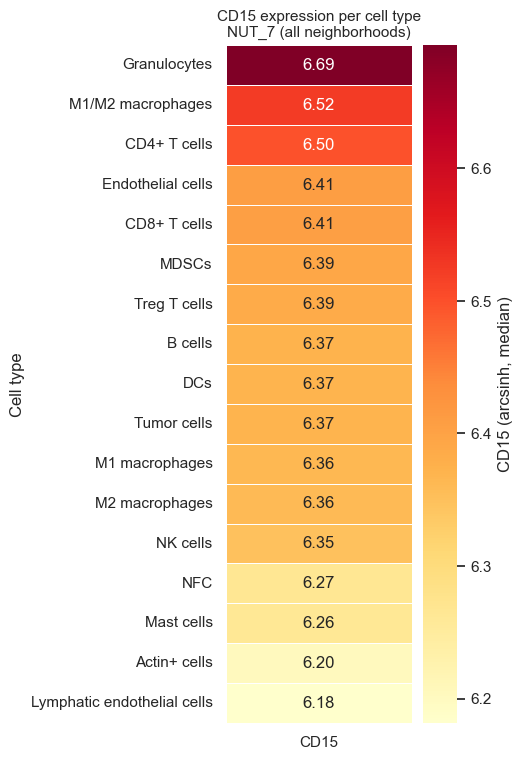

In [63]:
mask = adata_unified.obs["patient_ID"] == "NUT_7"
adata_sub = adata_unified[mask]
#turn into a df
df = adata_sub.to_df()
df["cell_category"] = adata_sub.obs["cell_category"]
df = df[["cell_category", "CD15"]]
cd15_per_celltype = df.groupby("cell_category")["CD15"].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(3, len(cd15_per_celltype) * 0.4 + 2))

sns.heatmap(
    cd15_per_celltype.to_frame(),
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "CD15 (arcsinh, median)"}
)

ax.set_title("CD15 expression per cell type\nNUT_7 (all neighborhoods)", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("Cell type")
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

True True
High Granulocytic     7
High M2 Macrophage    6
Name: count, dtype: int64
   patient_ID  MDSC_proportion               group
0       NUT_1         0.011659  High M2 Macrophage
1       NUT_2         0.008566   High Granulocytic
2       NUT_4         0.028020   High Granulocytic
3       NUT_5         0.018111   High Granulocytic
4       NUT_6         0.000000  High M2 Macrophage
5       NUT_7         0.019079  High M2 Macrophage
6       NUT_8         0.027841   High Granulocytic
7       NUT_9         0.071243   High Granulocytic
8      NUT_12         0.001008  High M2 Macrophage
9      NUT_13         0.004126  High M2 Macrophage
10     NUT_14         0.002757  High M2 Macrophage
11     NUT_15         0.004678   High Granulocytic
12     NUT_16         0.085433   High Granulocytic

Mann-Whitney U p-value: 0.0221


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/1921566645.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/1921566645.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_54293/1921566645.py:54: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




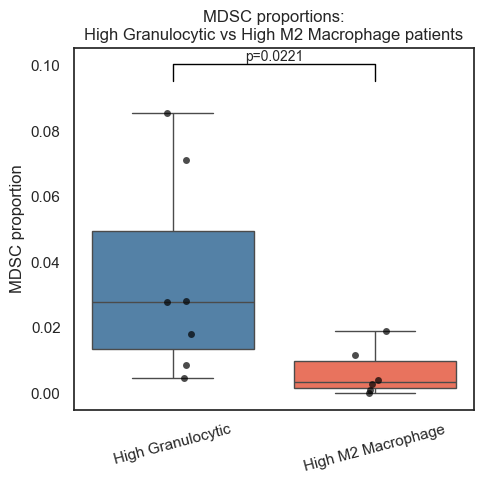

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# --- Get cell counts per patient ---
df = adata_unified.obs[["patient_ID", "patient_exp", "cell_category"]].copy()
df["cell_category"] = df["cell_category"].astype(str)

# Count per patient_exp (ROI) then mean per patient to handle multiple ROIs
counts_roi = df.groupby(["patient_ID", "patient_exp", "cell_category"]).size().unstack(fill_value=0)
counts_patient = counts_roi.groupby("patient_ID").mean()

# Compute proportions
proportions = counts_patient.div(counts_patient.sum(axis=1), axis=0)

# --- Classify patients ---
# Check columns exist
print("Granulocytes" in proportions.columns, "M2 macrophages" in proportions.columns)

granulocyte_prop = proportions["Granulocytes"]
m2_prop = proportions["M2 macrophages"]
mdsc_prop = proportions["MDSCs"]

# Patients with more granulocytes than M2 macrophages and vice versa
patient_group = pd.Series(index=proportions.index, dtype=str)
patient_group[granulocyte_prop > m2_prop] = "High Granulocytic"
patient_group[m2_prop > granulocyte_prop] = "High M2 Macrophage"

print(patient_group.value_counts())

# --- Build comparison df ---
compare_df = pd.DataFrame({
    "patient_ID": proportions.index,
    "MDSC_proportion": mdsc_prop.values,
    "group": patient_group.values
}).dropna()

print(compare_df)

# --- Stats ---
g1 = compare_df[compare_df["group"] == "High Granulocytic"]["MDSC_proportion"]
g2 = compare_df[compare_df["group"] == "High M2 Macrophage"]["MDSC_proportion"]
stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
print(f"\nMann-Whitney U p-value: {p:.4f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(5, 5))

palette = {"High Granulocytic": "steelblue", "High M2 Macrophage": "tomato"}
order = ["High Granulocytic", "High M2 Macrophage"]

sns.boxplot(data=compare_df, x="group", y="MDSC_proportion", order=order, palette=palette, ax=ax)
sns.stripplot(data=compare_df, x="group", y="MDSC_proportion", order=order,
              color="black", size=5, alpha=0.7, ax=ax)

# Bracket
y_max = compare_df["MDSC_proportion"].max() + 0.01
ax.plot([0, 0, 1, 1], [y_max, y_max + 0.005, y_max + 0.005, y_max], lw=1, color="black")
ax.text(0.5, y_max + 0.006, f"p={p:.4f}", ha="center", fontsize=10)

ax.set_title("MDSC proportions:\nHigh Granulocytic vs High M2 Macrophage patients")
ax.set_xlabel("")
ax.set_ylabel("MDSC proportion")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_19961/2223536032.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for roi, roi_df in obs_df.groupby("patient_exp"):


Niche-niche enrichment (log2 obs/exp):
                      Epithelial_adjacent  Lymphatic_immune  Lymphoid_B  \
Epithelial_adjacent                5.3200           -0.8500     -3.8600   
Lymphatic_immune                  -0.9400            3.0100      0.2600   
Lymphoid_B                        -4.2400            0.1700      5.8100   
Lymphoid_T                        -1.6500            0.2700      0.0200   
Lymphoid_enriched                 -3.9100            0.4100      1.1000   
Myeloid_granulocytic              -0.6500            0.0600     -3.0000   
Stromal_NFC                       -1.5300           -0.6900     -3.4500   
Stromal_fibroblasts               -3.8200           -0.1500     -1.0800   
Tumor_NFC                         -1.3700           -1.0300     -4.0000   
Tumor_bulk                        -4.4500           -3.8600     -7.2700   
Tumor_myeloid                     -1.5900           -0.1300     -3.4600   
Vascular/Endothelial              -1.4100           -0.0200  

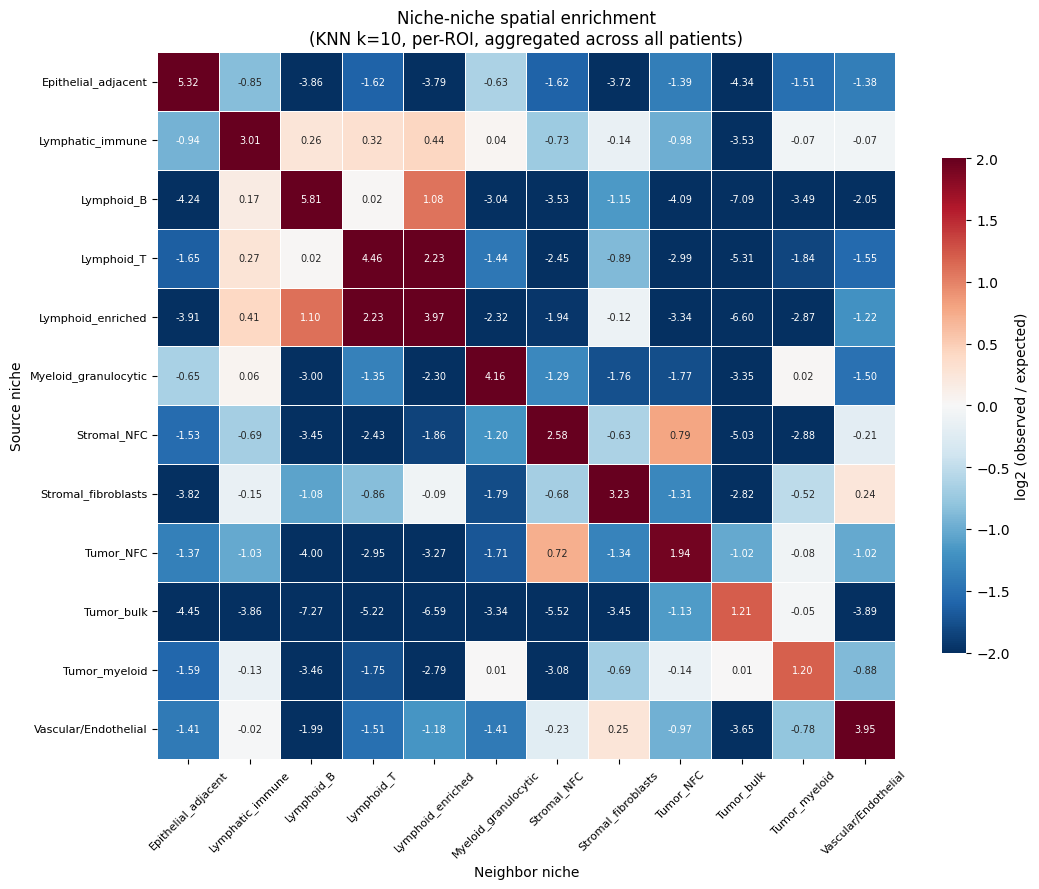

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

# ── build niche-niche neighbor counts per ROI, then aggregate ─────────────────
K = 10   # spatial neighbors per cell

valid  = adata.obs["neighborhood"].notna()
obs_df = adata.obs.loc[valid, ["patient_exp", "Cell Center X", "Cell Center Y", "neighborhood"]].copy()

niche_list   = sorted(obs_df["neighborhood"].unique())
n_niches     = len(niche_list)
niche_idx    = {n: i for i, n in enumerate(niche_list)}

# accumulate counts across all ROIs
agg_counts = np.zeros((n_niches, n_niches), dtype=float)

for roi, roi_df in obs_df.groupby("patient_exp"):
    if len(roi_df) < K + 1:
        continue
    coords = roi_df[["Cell Center X", "Cell Center Y"]].values
    labels = roi_df["neighborhood"].values

    nbrs = NearestNeighbors(n_neighbors=K + 1, algorithm="kd_tree").fit(coords)
    _, indices = nbrs.kneighbors(coords)

    for i, neighbors in enumerate(indices):
        src = niche_idx[labels[i]]
        for j in neighbors[1:]:           # skip self
            tgt = niche_idx[labels[j]]
            agg_counts[src, tgt] += 1

# ── compute enrichment: log2(observed / expected) ─────────────────────────────
# expected = freq_i * freq_j * total (random mixing null)
row_sums   = agg_counts.sum(axis=1, keepdims=True)
col_sums   = agg_counts.sum(axis=0, keepdims=True)
total      = agg_counts.sum()
expected   = (row_sums * col_sums) / total

enrichment = np.log2((agg_counts + 1) / (expected + 1))   # +1 pseudo-count

enr_df = pd.DataFrame(enrichment, index=niche_list, columns=niche_list)

print("Niche-niche enrichment (log2 obs/exp):")
print(enr_df.round(2))

# ── clustered heatmap ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    enr_df,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-2, vmax=2,
    linewidths=0.4,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"label": "log2 (observed / expected)", "shrink": 0.7},
)
ax.set_title(f"Niche-niche spatial enrichment\n(KNN k={K}, per-ROI, aggregated across all patients)",
             fontsize=12)
ax.set_xlabel("Neighbor niche", fontsize=10)
ax.set_ylabel("Source niche", fontsize=10)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import mannwhitneyu

# ── what to test ───────────────────────────────────────────────────────────────
# For each (cell_type, TLS niche), find markers higher than in Lymphatic_immune
queries = [
    ("B cells",      "Lymphoid_B"),
    ("B cells",      "Lymphoid_enriched"),
    ("CD8+ T cells", "Lymphoid_T"),
    ("CD8+ T cells", "Lymphoid_enriched"),
    ("CD4+ T cells", "Lymphoid_T"),
    ("CD4+ T cells", "Lymphoid_enriched"),
    ("Treg T cells", "Lymphoid_T"),
    ("Treg T cells", "Lymphoid_enriched"),
]
reference = "Lymphatic_immune"

# ── helpers ────────────────────────────────────────────────────────────────────
def _arcsinh(ad, marker, mask):
    col = ad[mask, marker].X
    if sp.issparse(col): col = col.toarray()
    return np.arcsinh(np.array(col, dtype=float).flatten())

def _patient_medians(obs_df, vals, group_col):
    df = obs_df.copy(); df["val"] = vals
    roi = df.groupby(["patient_ID", "patient_exp", group_col])["val"].median().reset_index()
    return roi.groupby(["patient_ID", group_col])["val"].median().reset_index()

# ── scan ───────────────────────────────────────────────────────────────────────
pd.set_option("display.float_format", "{:.4f}".format)

all_results = []

for cell_type, tls_nh in queries:
    mask = (
        (adata.obs["cell_category"] == cell_type) &
        (adata.obs["neighborhood"].isin([tls_nh, reference]))
    )
    if mask.sum() == 0:
        continue
    obs = adata.obs[mask][["patient_ID","patient_exp","neighborhood"]].reset_index(drop=True)

    for marker in markers:
        vals  = _arcsinh(adata, marker, mask)
        pat   = _patient_medians(obs, vals, "neighborhood")
        g_tls = pat[pat["neighborhood"] == tls_nh]["val"].dropna()
        g_ref = pat[pat["neighborhood"] == reference]["val"].dropna()
        if len(g_tls) < 3 or len(g_ref) < 3:
            continue
        _, pval = mannwhitneyu(g_tls, g_ref, alternative="greater")
        all_results.append({
            "cell_type":    cell_type,
            "TLS_niche":    tls_nh,
            "marker":       marker,
            "p_value":      pval,
            "median_TLS":   g_tls.median(),
            "median_ref":   g_ref.median(),
            "fold_diff":    g_tls.median() - g_ref.median(),
        })

res_df = pd.DataFrame(all_results).sort_values("p_value")
sig    = res_df[res_df["p_value"] < 0.05].copy()

print(f"Total tests: {len(res_df)}  |  p < 0.05 (one-sided, TLS > Lymphatic_immune): {len(sig)}\n")

# ── print results grouped by cell type + niche ─────────────────────────────────
for (ct, nh), grp in sig.groupby(["cell_type","TLS_niche"], sort=False):
    grp = grp.sort_values("p_value")
    print(f"{'━'*65}")
    print(f"  {ct}  |  {nh}  →  {len(grp)} marker(s) higher than {reference}")
    print(f"{'━'*65}")
    print(grp[["marker","p_value","median_TLS","median_ref","fold_diff"]].to_string(index=False))
    print()

In [ ]:
# ── Identify per-patient GALECTIN9 in MDSCs, Myeloid_granulocytic ─────────────
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

galectin_marker = [m for m in markers if "GALECTIN9" in m.upper()][0]

mask = (
    (adata.obs["cell_category"] == "MDSCs") &
    (adata.obs["neighborhood"] == "Myeloid_granulocytic")
)
obs = adata.obs[mask][["patient_ID", "patient_exp"]].reset_index(drop=True)
col = adata[mask, galectin_marker].X
if sp.issparse(col): col = col.toarray()
obs["val"] = np.arcsinh(np.array(col, dtype=float).flatten())

# median per ROI → median per patient
roi_df = obs.groupby(["patient_ID", "patient_exp"])["val"].median().reset_index()
pat_df = roi_df.groupby("patient_ID")["val"].median().reset_index().sort_values("val", ascending=False)

print(f"GALECTIN9 ({galectin_marker}) in MDSCs — Myeloid_granulocytic\nRanked by median expression per patient:\n")
print(pat_df.to_string(index=False))

# ── ranked dot plot ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#D62728" if v >= pat_df["val"].quantile(0.6) else
          "#1F77B4" if v <= pat_df["val"].quantile(0.4) else
          "#AAAAAA"
          for v in pat_df["val"]]

ax.scatter(range(len(pat_df)), pat_df["val"], c=colors, s=80, zorder=3)
ax.set_xticks(range(len(pat_df)))
ax.set_xticklabels(pat_df["patient_ID"], rotation=45, ha="right", fontsize=9)
ax.axhline(pat_df["val"].quantile(0.6), color="#D62728", lw=1, ls="--", alpha=0.5, label="top 40% threshold")
ax.axhline(pat_df["val"].quantile(0.4), color="#1F77B4", lw=1, ls="--", alpha=0.5, label="bottom 40% threshold")
ax.set_ylabel(f"{galectin_marker} (arcsinh, median per patient)", fontsize=10)
ax.set_title("GALECTIN9 in MDSCs — Myeloid_granulocytic\n(red = high, blue = low, grey = intermediate)", fontsize=11)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# ── shared helpers ─────────────────────────────────────────────────────────────
def _get(marker):
    """Return marker name from `markers` vector (case-insensitive partial match)."""
    hits = [m for m in markers if marker.upper() in m.upper()]
    if not hits:
        raise KeyError(f"'{marker}' not found in markers vector")
    return hits[0]

def _arcsinh(ad, marker, mask):
    col = ad[mask, marker].X
    if sp.issparse(col): col = col.toarray()
    return np.arcsinh(np.array(col, dtype=float).flatten())

def _patient_medians(obs_series, vals, groupby_cols):
    """median per ROI → median per patient, returns Series per patient."""
    df = obs_series.copy()
    df["val"] = vals
    roi = df.groupby(groupby_cols + ["patient_exp"])["val"].median().reset_index()
    return roi.groupby(groupby_cols)["val"].median().reset_index()

def _boxplot(ax, pat_df, group_col, val_col, order, palette, title, ylabel):
    sns.boxplot(data=pat_df, x=group_col, y=val_col, order=order,
                palette=palette, width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=pat_df, x=group_col, y=val_col, order=order,
                  color="black", size=4, alpha=0.7, jitter=True, ax=ax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticklabels([o.replace("_", "\n") for o in order], fontsize=8)

def _bracket(ax, x1, x2, y, p, gap=0.05):
    ax.plot([x1,x1,x2,x2],[y, y+gap*0.6, y+gap*0.6, y], lw=1, color="black")
    label = f"p={p:.4f}" + (" *" if p < 0.05 else "")
    ax.text((x1+x2)/2, y+gap*0.7, label, ha="center", va="bottom", fontsize=8)

print("Markers resolved:")
for name in ["GALECTIN9","CD112","HLADR","BCL2","GLUT1"]:
    try: print(f"  {name} → {_get(name)}")
    except KeyError as e: print(f"  {e}")

# ══════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS 1 — Checkpoint ligands (GALECTIN9, CD112) in MDSCs
#               Myeloid_granulocytic vs Lymphatic_immune
# ══════════════════════════════════════════════════════════════════════════════
h1_markers = []
for name in ["GALECTIN9", "CD112"]:
    try: h1_markers.append(_get(name))
    except KeyError: pass

fig1, axes1 = plt.subplots(1, len(h1_markers), figsize=(4*len(h1_markers), 5))
if len(h1_markers) == 1: axes1 = [axes1]
fig1.suptitle("H1 — Checkpoint ligands in MDSCs\nMyeloid_granulocytic vs Lymphatic_immune", fontsize=11)

for ax, marker in zip(axes1, h1_markers):
    nh_pair = ["Myeloid_granulocytic", "Lymphatic_immune"]
    mask = (adata.obs["cell_category"] == "MDSCs") & (adata.obs["neighborhood"].isin(nh_pair))
    obs  = adata.obs[mask][["patient_ID","patient_exp","neighborhood"]].reset_index(drop=True)
    obs["val"] = _arcsinh(adata, marker, mask)
    pat  = _patient_medians(obs, obs["val"].values, ["patient_ID","neighborhood"])
    g_a  = pat[pat["neighborhood"] == "Myeloid_granulocytic"]["val"].dropna()
    g_b  = pat[pat["neighborhood"] == "Lymphatic_immune"]["val"].dropna()
    _, p = mannwhitneyu(g_a, g_b, alternative="two-sided")
    _boxplot(ax, pat, "neighborhood", "val", nh_pair,
             {"Myeloid_granulocytic":"#B85AA6","Lymphatic_immune":"#00BFC4"},
             marker, "arcsinh")
    y_top = pat["val"].max()
    _bracket(ax, 0, 1, y_top + 0.05, p)

plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS 2 — HLA-DR in MDSCs vs M1 vs M2 macrophages within Tumor_myeloid
# ══════════════════════════════════════════════════════════════════════════════
hladr = _get("HLADR")
cell_types_h2 = ["MDSCs", "M1 macrophages", "M2 macrophages"]
palette_h2    = {"MDSCs":"#332288","M1 macrophages":"#00557F","M2 macrophages":"#66A61E"}

mask_h2 = (adata.obs["cell_category"].isin(cell_types_h2)) & (adata.obs["neighborhood"] == "Tumor_myeloid")
obs_h2  = adata.obs[mask_h2][["patient_ID","patient_exp","cell_category"]].reset_index(drop=True)
obs_h2["val"] = _arcsinh(adata, hladr, mask_h2)

pat_h2 = _patient_medians(obs_h2, obs_h2["val"].values, ["patient_ID","cell_category"])

fig2, ax2 = plt.subplots(figsize=(5, 5))
fig2.suptitle("H2 — HLA-DR within Tumor_myeloid\nMDSCs vs macrophages", fontsize=11)
_boxplot(ax2, pat_h2, "cell_category", "val", cell_types_h2, palette_h2, hladr, "arcsinh")

pairs_h2 = [("MDSCs","M1 macrophages",0,1), ("MDSCs","M2 macrophages",0,2)]
y_base = pat_h2["val"].max()
for ct_a, ct_b, x1, x2 in pairs_h2:
    g_a = pat_h2[pat_h2["cell_category"]==ct_a]["val"].dropna()
    g_b = pat_h2[pat_h2["cell_category"]==ct_b]["val"].dropna()
    if len(g_a) >= 3 and len(g_b) >= 3:
        _, p = mannwhitneyu(g_a, g_b, alternative="two-sided")
        _bracket(ax2, x1, x2, y_base + 0.05*(x2-x1)*0.8, p, gap=0.07)

plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS 3 — BCL2 (survival) in MDSCs: Tumor_myeloid vs Myeloid_granulocytic
# ══════════════════════════════════════════════════════════════════════════════
bcl2 = _get("BCL2")
nh_h3 = ["Tumor_myeloid", "Myeloid_granulocytic"]

mask_h3 = (adata.obs["cell_category"] == "MDSCs") & (adata.obs["neighborhood"].isin(nh_h3))
obs_h3  = adata.obs[mask_h3][["patient_ID","patient_exp","neighborhood"]].reset_index(drop=True)
obs_h3["val"] = _arcsinh(adata, bcl2, mask_h3)
pat_h3 = _patient_medians(obs_h3, obs_h3["val"].values, ["patient_ID","neighborhood"])

g_a = pat_h3[pat_h3["neighborhood"]=="Tumor_myeloid"]["val"].dropna()
g_b = pat_h3[pat_h3["neighborhood"]=="Myeloid_granulocytic"]["val"].dropna()
_, p_h3 = mannwhitneyu(g_a, g_b, alternative="two-sided")

fig3, ax3 = plt.subplots(figsize=(4, 5))
fig3.suptitle("H3 — BCL2 (survival) in MDSCs\nTumor_myeloid vs Myeloid_granulocytic", fontsize=11)
_boxplot(ax3, pat_h3, "neighborhood", "val", nh_h3,
         {"Tumor_myeloid":"#9D2449","Myeloid_granulocytic":"#B85AA6"}, bcl2, "arcsinh")
_bracket(ax3, 0, 1, pat_h3["val"].max() + 0.05, p_h3)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS 4 — GLUT1 (metabolic) in MDSCs across 3 niches
#               Lymphatic_immune as control
# ══════════════════════════════════════════════════════════════════════════════
glut1 = _get("GLUT1")
nh_h4  = ["Tumor_myeloid", "Myeloid_granulocytic", "Lymphatic_immune"]
pal_h4 = {"Tumor_myeloid":"#9D2449","Myeloid_granulocytic":"#B85AA6","Lymphatic_immune":"#00BFC4"}

mask_h4 = (adata.obs["cell_category"] == "MDSCs") & (adata.obs["neighborhood"].isin(nh_h4))
obs_h4  = adata.obs[mask_h4][["patient_ID","patient_exp","neighborhood"]].reset_index(drop=True)
obs_h4["val"] = _arcsinh(adata, glut1, mask_h4)
pat_h4 = _patient_medians(obs_h4, obs_h4["val"].values, ["patient_ID","neighborhood"])

fig4, ax4 = plt.subplots(figsize=(5, 5))
fig4.suptitle("H4 — GLUT1 (metabolism) in MDSCs\nacross niches (Lymphatic_immune = control)", fontsize=11)
_boxplot(ax4, pat_h4, "neighborhood", "val", nh_h4, pal_h4, glut1, "arcsinh")

y_base = pat_h4["val"].max()
for (ct_a, ct_b, x1, x2, offset) in [
    ("Tumor_myeloid","Lymphatic_immune", 0, 2, 0.0),
    ("Myeloid_granulocytic","Lymphatic_immune", 1, 2, 0.25),
]:
    g_a = pat_h4[pat_h4["neighborhood"]==ct_a]["val"].dropna()
    g_b = pat_h4[pat_h4["neighborhood"]==ct_b]["val"].dropna()
    if len(g_a) >= 3 and len(g_b) >= 3:
        _, p = mannwhitneyu(g_a, g_b, alternative="two-sided")
        _bracket(ax4, x1, x2, y_base + 0.05 + offset, p, gap=0.07)

plt.tight_layout(); plt.show()

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# ── comparisons to run  (cell_type, niche_A, niche_B, direction) ──────────────
# direction: "greater" = A > B, "two-sided" = any difference
comparisons = [
    # T cell niches
    ("CD8+ T cells",      "Lymphoid_T",         "Lymphatic_immune",    "two-sided"),
    ("CD4+ T cells",      "Lymphoid_T",         "Lymphatic_immune",    "two-sided"),
    ("Treg T cells",      "Lymphoid_T",         "Lymphatic_immune",    "two-sided"),
    # B cell / TLS
    ("B cells",           "Lymphoid_B",         "Lymphatic_immune",    "two-sided"),
    ("PCs",               "Lymphoid_B",         "Lymphatic_immune",    "two-sided"),
    # NK
    ("NK cells",          "Lymphoid_enriched",  "Lymphatic_immune",    "two-sided"),
    # Myeloid
    ("MDSCs",             "Myeloid_granulocytic","Lymphatic_immune",   "two-sided"),
    ("Granulocytes",      "Myeloid_granulocytic","Lymphatic_immune",   "two-sided"),
    ("M2 macrophages",    "Tumor_myeloid",       "Lymphatic_immune",   "two-sided"),
    ("M1 macrophages",    "Tumor_myeloid",       "Lymphatic_immune",   "two-sided"),
    # within-niche cell-type contrasts
    ("CD8+ T cells",      "Lymphoid_T",         "Lymphoid_B",          "two-sided"),
    ("B cells",           "Lymphoid_B",         "Lymphoid_T",          "two-sided"),
    ("MDSCs",             "Myeloid_granulocytic","Tumor_myeloid",      "two-sided"),
    ("M2 macrophages",    "Tumor_myeloid",       "Myeloid_granulocytic","two-sided"),
]

# ── helper ─────────────────────────────────────────────────────────────────────
def _dense_arcsinh(ad, var, mask):
    col = ad[mask, var].X
    if sp.issparse(col): col = col.toarray()
    return np.arcsinh(np.array(col, dtype=float).flatten())

def _aggregate(obs_df, vals, nh_col="neighborhood"):
    obs_df = obs_df.copy()
    obs_df["val"] = vals
    roi = obs_df.groupby(["patient_ID","patient_exp", nh_col])["val"].median().reset_index()
    return roi.groupby(["patient_ID", nh_col])["val"].median().reset_index()

# ── scan ───────────────────────────────────────────────────────────────────────
results = []
for cell_type, nh_a, nh_b, alt in comparisons:
    mask = (
        (adata.obs["cell_category"] == cell_type) &
        (adata.obs["neighborhood"].isin([nh_a, nh_b]))
    )
    if mask.sum() == 0:
        continue
    obs_base = adata.obs[mask][["patient_ID","patient_exp","neighborhood"]].reset_index(drop=True)

    for marker in markers:
        vals = _dense_arcsinh(adata, marker, mask)
        pat  = _aggregate(obs_base, vals)
        g_a  = pat[pat["neighborhood"] == nh_a]["val"].dropna()
        g_b  = pat[pat["neighborhood"] == nh_b]["val"].dropna()
        if len(g_a) < 3 or len(g_b) < 3:
            continue
        _, pval = mannwhitneyu(g_a, g_b, alternative=alt)
        results.append({
            "cell_type": cell_type, "marker": marker,
            "nh_a": nh_a, "nh_b": nh_b,
            "p_value": pval,
            "median_a": g_a.median(), "median_b": g_b.median(),
            "direction": "A>B" if g_a.median() > g_b.median() else "A<B",
            "n_a": len(g_a), "n_b": len(g_b),
            "_g_a": g_a, "_g_b": g_b,
        })

res_df = pd.DataFrame(results).sort_values("p_value")
sig     = res_df[res_df["p_value"] < 0.05].copy()
print(f"Total comparisons: {len(res_df)}  |  p < 0.05: {len(sig)}")
pd.set_option("display.float_format", "{:.4f}".format)
print(sig[["cell_type","marker","nh_a","nh_b","p_value","median_a","median_b","direction"]].to_string(index=False))

# ── boxplots for top 12 hits ───────────────────────────────────────────────────
top = sig.head(12)
ncols = 3
nrows = int(np.ceil(len(top) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4.5))
axes = axes.flatten()

for i, row in enumerate(top.itertuples()):
    ax  = axes[i]
    g_a = row._g_a.reset_index(drop=True)
    g_b = row._g_b.reset_index(drop=True)
    plot_df = pd.DataFrame({
        "val": pd.concat([g_a, g_b], ignore_index=True),
        "group": [row.nh_a] * len(g_a) + [row.nh_b] * len(g_b),
    })
    order = [row.nh_a, row.nh_b]
    sns.boxplot(data=plot_df, x="group", y="val", order=order,
                palette={row.nh_a: "#4C8FC0", row.nh_b: "#E07B54"},
                width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=plot_df, x="group", y="val", order=order,
                  color="black", size=4, alpha=0.7, jitter=True, ax=ax)

    y_top  = plot_df["val"].max()
    y_line = y_top + 0.05
    ax.plot([0, 0, 1, 1], [y_line, y_line+0.03, y_line+0.03, y_line], lw=1, color="black")
    ax.text(0.5, y_line+0.04, f"p={row.p_value:.4f}", ha="center", fontsize=8)

    short_a = row.nh_a.replace("_", "\n")
    short_b = row.nh_b.replace("_", "\n")
    ax.set_xticklabels([short_a, short_b], fontsize=7)
    ax.set_title(f"{row.cell_type}\n{row.marker}", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("arcsinh", fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top significant marker differences (p < 0.05, uncorrected)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# ── get HLADR marker name from the markers vector ─────────────────────────────
hladr_marker = [m for m in markers if "HLADR" in m.upper()]
print("HLADR in markers:", hladr_marker)
hladr_marker = hladr_marker[0]

# ── filter: B cells, two neighborhoods ────────────────────────────────────────
neighborhoods = ["Lymphoid_B", "Lymphatic_immune"]
cell_mask = (
    (adata.obs["cell_category"] == "B cells") &
    (adata.obs["neighborhood"].isin(neighborhoods))
)

col = adata[cell_mask, hladr_marker].X
if sp.issparse(col): col = col.toarray()
hladr_arcsinh = np.arcsinh(np.array(col, dtype=float).flatten())

obs_df = adata.obs[cell_mask][["patient_ID", "patient_exp", "neighborhood"]].copy().reset_index(drop=True)
obs_df["HLADR"] = hladr_arcsinh

print(f"B cells retained: {cell_mask.sum()}")
print(obs_df.groupby("neighborhood").size())

# ── median per ROI → median per patient ───────────────────────────────────────
roi_df = obs_df.groupby(["patient_ID", "patient_exp", "neighborhood"])["HLADR"].median().reset_index()
pat_df = roi_df.groupby(["patient_ID", "neighborhood"])["HLADR"].median().reset_index()

g_lb = pat_df[pat_df["neighborhood"] == "Lymphoid_B"]["HLADR"].dropna()
g_li = pat_df[pat_df["neighborhood"] == "Lymphatic_immune"]["HLADR"].dropna()

_, pval = mannwhitneyu(g_lb, g_li, alternative="greater")
print(f"\nMann-Whitney U  Lymphoid_B > Lymphatic_immune  p = {pval:.4f}")

# ── plot ───────────────────────────────────────────────────────────────────────
order   = ["Lymphoid_B", "Lymphatic_immune"]
palette = {"Lymphoid_B": "#E6C84F", "Lymphatic_immune": "#00BFC4"}

fig, ax = plt.subplots(figsize=(4, 5))
sns.boxplot(data=pat_df, x="neighborhood", y="HLADR",
            order=order, palette=palette, width=0.5, fliersize=0, ax=ax)
sns.stripplot(data=pat_df, x="neighborhood", y="HLADR",
              order=order, color="black", size=5, alpha=0.7, jitter=True, ax=ax)

y_max  = pat_df["HLADR"].max()
y_line = y_max + 0.1
ax.plot([0, 0, 1, 1], [y_line, y_line + 0.05, y_line + 0.05, y_line], lw=1.2, color="black")
p_label = f"p = {pval:.4f}" + (" *" if pval < 0.05 else " (ns)")
ax.text(0.5, y_line + 0.07, p_label, ha="center", va="bottom", fontsize=10)

ax.set_title(f"HLA-DR ({hladr_marker}) in B cells\nLymphoid_B vs Lymphatic_immune", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("HLA-DR (arcsinh, median per patient)", fontsize=10)
ax.set_xticklabels(["Lymphoid_B", "Lymphatic\nimmune"], fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import scanpy as sc
import numpy as np
import scipy.sparse as sp

# work on a copy — never touch the original adata
adata_plot = adata[:, markers].copy()

# arcsinh-transform into a layer, use that for plotting
X = adata_plot.X
if sp.issparse(X):
    X = X.toarray()
adata_plot.layers["arcsinh"] = np.arcsinh(X.astype(float))

# stacked violin: markers vs neighborhoods
plot = sc.pl.stacked_violin(
    adata_plot,
    markers,
    groupby="neighborhood",
    layer="arcsinh",
    use_raw=False,
    density_norm="area",
    figsize=(16, 7),
    return_fig=True,
)
plot.add_totals()
axes = plot.get_axes()

ax = axes["mainplot_ax"]
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=90)

group_ax = axes["group_extra_ax"]
for text in group_ax.texts:
    text.set_fontsize(10)

cax = axes["color_legend_ax"]
cax.set_title("scaled mean\nexpression", fontsize=9)

ax.figure.suptitle("Marker expression (arcsinh) across neighborhoods", fontsize=13, y=1.02)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import mannwhitneyu

# ── cell type → their most specific neighborhood ──────────────────────────────
# adjust this mapping if you disagree with any pairing
cell_type_to_neighborhood = {
    "CD8+ T cells":      "Lymphoid_T",
    "CD4+ T cells":      "Lymphoid_T",
    "Treg T cells":      "Lymphoid_T",
    "NK cells":          "Lymphoid_enriched",
    "B cells":           "Lymphoid_B",
    "PCs":               "Lymphoid_B",
    "MDSCs":             "Myeloid_granulocytic",
    "Granulocytes":      "Myeloid_granulocytic",
    "DCs":               "Myeloid_granulocytic",
    "Mast cells":        "Myeloid_granulocytic",
    "M1 macrophages":    "Tumor_myeloid",
    "M2 macrophages":    "Tumor_myeloid",
    "M1/M2 macrophages": "Tumor_myeloid",
}
reference = "Lymphatic_immune"

# ── helper ─────────────────────────────────────────────────────────────────────
def _dense(ad, var):
    col = ad[:, var].X
    if sp.issparse(col):
        col = col.toarray()
    return np.arcsinh(np.array(col, dtype=float).flatten())

# ── run per cell type ──────────────────────────────────────────────────────────
pd.set_option("display.float_format", "{:.4f}".format)

for cell_type, home_nh in cell_type_to_neighborhood.items():

    cell_mask = (
        (adata.obs["cell_category"] == cell_type) &
        (adata.obs["neighborhood"].isin([home_nh, reference]))
    )
    if cell_mask.sum() == 0:
        continue

    obs_df = adata.obs[cell_mask][["patient_ID", "patient_exp", "neighborhood"]].copy().reset_index(drop=True)

    results = []
    for marker in markers:
        col = _dense(adata[cell_mask], marker)
        df  = obs_df.copy()
        df["val"] = col

        roi_df = df.groupby(["patient_ID", "patient_exp", "neighborhood"])["val"].median().reset_index()
        pat_df = roi_df.groupby(["patient_ID", "neighborhood"])["val"].median().reset_index()

        g_home = pat_df[pat_df["neighborhood"] == home_nh]["val"].dropna()
        g_ref  = pat_df[pat_df["neighborhood"] == reference]["val"].dropna()

        if len(g_home) < 3 or len(g_ref) < 3:
            continue

        _, pval = mannwhitneyu(g_home, g_ref, alternative="two-sided")
        results.append({
            "marker":      marker,
            "p_value":     pval,
            "median_home": g_home.median(),
            "median_ref":  g_ref.median(),
            "direction":   "up" if g_home.median() > g_ref.median() else "down",
            "n_home":      len(g_home),
            "n_ref":       len(g_ref),
        })

    if not results:
        continue

    res_df = pd.DataFrame(results).sort_values("p_value")
    sig    = res_df[res_df["p_value"] < 0.05]

    n_home = obs_df[obs_df["neighborhood"] == home_nh]["patient_ID"].nunique()
    n_ref  = obs_df[obs_df["neighborhood"] == reference]["patient_ID"].nunique()
    print(f"\n{'═'*70}")
    print(f"  {cell_type}  |  {home_nh} vs {reference}  "
          f"(n={n_home} vs n={n_ref} patients)")
    print(f"{'═'*70}")
    if len(sig):
        print(sig[["marker", "p_value", "median_home", "median_ref", "direction"]].to_string(index=False))
    else:
        print("  No markers reached p < 0.05")

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import mannwhitneyu

# ── settings ───────────────────────────────────────────────────────────────────
test_neighborhoods = ["Lymphoid_T", "Lymphoid_enriched"]
reference          = "Lymphatic_immune"
cell_type          = "CD8+ T cells"

# ── filter cells ───────────────────────────────────────────────────────────────
keep_nh   = test_neighborhoods + [reference]
cell_mask = (
    (adata.obs["cell_category"] == cell_type) &
    (adata.obs["neighborhood"].isin(keep_nh))
)
obs_df = adata.obs[cell_mask][["patient_ID", "patient_exp", "neighborhood"]].copy().reset_index(drop=True)
print(f"{cell_mask.sum()} {cell_type} cells | {obs_df['patient_ID'].nunique()} patients")
print(obs_df.groupby("neighborhood").size())

# ── test only markers in the `markers` vector ─────────────────────────────────
all_results = []

for marker in markers:
    col = adata[cell_mask, marker].X
    if sp.issparse(col):
        col = col.toarray()
    col_arcsinh = np.arcsinh(np.array(col, dtype=float).flatten())

    df = obs_df.copy()
    df["val"] = col_arcsinh

    roi_df = df.groupby(["patient_ID", "patient_exp", "neighborhood"])["val"].median().reset_index()
    pat_df = roi_df.groupby(["patient_ID", "neighborhood"])["val"].median().reset_index()

    ref_vals = pat_df[pat_df["neighborhood"] == reference]["val"].dropna()
    if len(ref_vals) < 3:
        continue

    for nh in test_neighborhoods:
        test_vals = pat_df[pat_df["neighborhood"] == nh]["val"].dropna()
        if len(test_vals) < 3:
            continue
        _, pval = mannwhitneyu(test_vals, ref_vals, alternative="greater")
        all_results.append({
            "marker":       marker,
            "comparison":   f"{nh} > {reference}",
            "p_value":      pval,
            "median_test":  test_vals.median(),
            "median_ref":   ref_vals.median(),
        })

res_df = pd.DataFrame(all_results).sort_values("p_value")
pd.set_option("display.float_format", "{:.4f}".format)

for nh in test_neighborhoods:
    subset = res_df[
        (res_df["comparison"].str.startswith(nh)) &
        (res_df["p_value"] < 0.05)
    ][["marker", "p_value", "median_test", "median_ref"]]
    print(f"\n── {nh} > {reference}  |  p < 0.05 ──────────────────────────")
    print(subset.to_string(index=False) if len(subset) else "  None")

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import mannwhitneyu

# ── helper ─────────────────────────────────────────────────────────────────────
def _dense(ad, var):
    col = ad[:, var].X
    if sp.issparse(col):
        col = col.toarray()
    return np.array(col, dtype=float).flatten()

# ── print available neighborhoods for reference ────────────────────────────────
print("Available neighborhoods:", sorted(adata.obs["neighborhood"].dropna().unique()))

# ── settings — adjust neighborhood names here if needed ───────────────────────
test_neighborhoods = ["Lymphoid_T", "Lymphoid_enriched"]   # groups to test as "higher"
reference          = "Lymphatic_immune"                     # reference group
cell_type          = "CD8+ T cells"

# ── filter cells ───────────────────────────────────────────────────────────────
keep_nh  = test_neighborhoods + [reference]
cell_mask = (
    (adata.obs["cell_category"] == cell_type) &
    (adata.obs["neighborhood"].isin(keep_nh))
)
obs_df = adata.obs[cell_mask][["patient_ID", "patient_exp", "neighborhood"]].copy().reset_index(drop=True)
print(f"\n{cell_mask.sum()} {cell_type} cells retained across {obs_df['patient_ID'].nunique()} patients")
print(obs_df.groupby("neighborhood").size())

# ── build deduplicated base marker list ────────────────────────────────────────
import re
base_names, seen = [], set()
for v in adata.var_names:
    base = re.sub(r'\s+\d+$', '', v).strip()
    if base not in seen:
        seen.add(base)
        base_names.append(base)

# ── test each marker: test_neighborhood > reference (one-sided) ───────────────
all_results = []

for base in base_names:
    # merge duplicates on-the-fly (same logic as KI67 merge, no adata mutation)
    dupes = [v for v in adata.var_names
             if re.sub(r'\s+\d+$', '', v).strip().upper() == base.upper()]
    if len(dupes) == 1:
        col_full = np.arcsinh(_dense(adata, dupes[0]))
    else:
        cols = np.column_stack([_dense(adata, v) for v in dupes])
        merged = np.full(cols.shape[0], np.nan)
        for c in range(cols.shape[1]):
            m = np.isnan(merged)
            merged[m] = cols[m, c]
        col_full = np.arcsinh(merged)

    col_sub = col_full[cell_mask.values]
    df = obs_df.copy()
    df["val"] = col_sub

    # median per ROI → median per patient
    roi_df = df.groupby(["patient_ID", "patient_exp", "neighborhood"])["val"].median().reset_index()
    pat_df = roi_df.groupby(["patient_ID", "neighborhood"])["val"].median().reset_index()

    ref_vals = pat_df[pat_df["neighborhood"] == reference]["val"].dropna()
    if len(ref_vals) < 3:
        continue

    for nh in test_neighborhoods:
        test_vals = pat_df[pat_df["neighborhood"] == nh]["val"].dropna()
        if len(test_vals) < 3:
            continue
        stat, pval = mannwhitneyu(test_vals, ref_vals, alternative="greater")
        all_results.append({
            "marker":    base,
            "comparison": f"{nh} > {reference}",
            "p_value":   pval,
            "median_test": test_vals.median(),
            "median_ref":  ref_vals.median(),
            "n_test":    len(test_vals),
            "n_ref":     len(ref_vals),
        })

res_df = pd.DataFrame(all_results).sort_values("p_value")

# ── print nominally significant results (p < 0.05, no correction) ─────────────
pd.set_option("display.float_format", "{:.4f}".format)

for nh in test_neighborhoods:
    subset = res_df[
        (res_df["comparison"].str.startswith(nh)) &
        (res_df["p_value"] < 0.05)
    ][["marker", "p_value", "median_test", "median_ref", "n_test", "n_ref"]]
    print(f"\n── {nh} > {reference}  |  p < 0.05 (no correction) ──────────────")
    if len(subset):
        print(subset.to_string(index=False))
    else:
        print("No markers reached p < 0.05")

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ── helpers ────────────────────────────────────────────────────────────────────
def _dense(ad, var):
    col = ad[:, var].X
    if sp.issparse(col):
        col = col.toarray()
    return np.array(col, dtype=float).flatten()

def _merged_col(ad, base_name):
    """Return arcsinh-transformed column, merging duplicate vars if present."""
    dupes = [v for v in ad.var_names if v.upper() == base_name.upper()
             or v.upper().startswith(base_name.upper() + " ")]
    if len(dupes) == 1:
        vals = _dense(ad, dupes[0])
    else:
        # same logic as KI67 merge: use first non-NaN per cell
        cols = np.column_stack([_dense(ad, v) for v in dupes])
        vals = np.full(cols.shape[0], np.nan)
        for c in range(cols.shape[1]):
            mask = np.isnan(vals)
            vals[mask] = cols[mask, c]
    return np.arcsinh(vals)

# ── build base obs dataframe ───────────────────────────────────────────────────
neighborhoods = ["Myeloid_granulocytic", "Lymphatic_immune"]
cell_mask = (
    (adata.obs["cell_category"] == "MDSCs") &
    (adata.obs["neighborhood"].isin(neighborhoods))
)
adata_sub = adata[cell_mask]

obs_df = adata_sub.obs[["patient_ID", "patient_exp", "neighborhood"]].copy().reset_index(drop=True)

# ── deduplicate var list (keep unique base names) ─────────────────────────────
seen, unique_vars = set(), []
for v in adata.var_names:
    base = v.strip()
    if base not in seen:
        seen.add(base)
        unique_vars.append(v)
# also collapse anything that looks like "MARKER 1" -> already handled by _merged_col
# build a clean list of base names (drop " 1", " 2" suffixes)
import re
base_names_ordered = []
seen_bases = set()
for v in adata.var_names:
    base = re.sub(r'\s+\d+$', '', v).strip()
    if base not in seen_bases:
        seen_bases.add(base)
        base_names_ordered.append(base)

print(f"Testing {len(base_names_ordered)} unique markers on {cell_mask.sum()} MDSCs "
      f"across {obs_df['patient_ID'].nunique()} patients...")

# ── run test for every marker ──────────────────────────────────────────────────
results = []
for base in base_names_ordered:
    # get merged arcsinh col aligned to adata_sub
    col_full = _merged_col(adata, base)          # length = all cells
    col_sub  = col_full[cell_mask.values]        # filter to MDSCs in 2 neighborhoods

    df = obs_df.copy()
    df["val"] = col_sub

    # median per ROI → median per patient
    roi_df = df.groupby(["patient_ID", "patient_exp", "neighborhood"])["val"].median().reset_index()
    pat_df = roi_df.groupby(["patient_ID", "neighborhood"])["val"].median().reset_index()

    g1 = pat_df[pat_df["neighborhood"] == "Myeloid_granulocytic"]["val"].dropna()
    g2 = pat_df[pat_df["neighborhood"] == "Lymphatic_immune"]["val"].dropna()

    if len(g1) < 3 or len(g2) < 3:
        continue

    stat, pval = mannwhitneyu(g1, g2, alternative="two-sided")
    results.append({
        "marker":  base,
        "p_value": pval,
        "median_Myeloid_granulocytic": g1.median(),
        "median_Lymphatic_immune":     g2.median(),
        "n_Myeloid": len(g1),
        "n_Lymphatic": len(g2),
    })

res_df = pd.DataFrame(results)
_, p_adj, _, _ = multipletests(res_df["p_value"], method="fdr_bh")
res_df["p_adj"] = p_adj
res_df = res_df.sort_values("p_value")

print("\n── All markers sorted by p-value ──────────────────────────────────────")
pd.set_option("display.float_format", "{:.4f}".format)
print(res_df[["marker", "p_value", "p_adj",
              "median_Myeloid_granulocytic", "median_Lymphatic_immune"]].to_string(index=False))

sig = res_df[res_df["p_adj"] < 0.05]
print(f"\n── Significant after FDR (p_adj < 0.05): {len(sig)} markers ──")
if len(sig):
    print(sig[["marker", "p_value", "p_adj",
               "median_Myeloid_granulocytic", "median_Lymphatic_immune"]].to_string(index=False))
else:
    print("None after FDR correction.")
    print("\nNominal p < 0.05 (uncorrected):")
    print(res_df[res_df["p_value"] < 0.05][
        ["marker", "p_value", "median_Myeloid_granulocytic", "median_Lymphatic_immune"]
    ].to_string(index=False))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import mannwhitneyu

# --- Extract KI67 raw values and arcsinh-transform ---
ki67_col = adata[:, "KI67"].X
if sp.issparse(ki67_col):
    ki67_col = ki67_col.toarray()
ki67_arcsinh = np.arcsinh(np.array(ki67_col, dtype=float).flatten())

# --- Build working dataframe ---
df = pd.DataFrame({
    "patient_ID":   adata.obs["patient_ID"].values,
    "patient_exp":  adata.obs["patient_exp"].values,
    "cell_category": adata.obs["cell_category"].values,
    "neighborhood": adata.obs["neighborhood"].values,
    "KI67":         ki67_arcsinh,
})

# --- Filter: MDSCs only, two neighborhoods of interest ---
neighborhoods = ["Myeloid_granulocytic", "Lymphatic_immune"]
df = df[
    (df["cell_category"] == "MDSCs") &
    (df["neighborhood"].isin(neighborhoods))
].copy()

print(f"Cells retained: {len(df)}")
print(df.groupby("neighborhood").size())

# --- Step 1: median per patient_exp (ROI) per neighborhood ---
roi_df = (
    df.groupby(["patient_ID", "patient_exp", "neighborhood"])["KI67"]
    .median()
    .reset_index()
)

# --- Step 2: median per patient_ID per neighborhood ---
patient_df = (
    roi_df.groupby(["patient_ID", "neighborhood"])["KI67"]
    .median()
    .reset_index()
)

print(f"\nPatients per neighborhood:")
print(patient_df.groupby("neighborhood").size())

# --- Wilcoxon / Mann-Whitney U ---
g1 = patient_df[patient_df["neighborhood"] == "Myeloid_granulocytic"]["KI67"].dropna()
g2 = patient_df[patient_df["neighborhood"] == "Lymphatic_immune"]["KI67"].dropna()
stat, pval = mannwhitneyu(g1, g2, alternative="two-sided")
print(f"\nMann-Whitney U p-value: {pval:.4f}")

# --- Boxplot ---
palette = {"Myeloid_granulocytic": "#B85AA6", "Lymphatic_immune": "#00BFC4"}
order   = ["Myeloid_granulocytic", "Lymphatic_immune"]

fig, ax = plt.subplots(figsize=(4, 5))

sns.boxplot(data=patient_df, x="neighborhood", y="KI67",
            order=order, palette=palette, width=0.5, fliersize=0, ax=ax)
sns.stripplot(data=patient_df, x="neighborhood", y="KI67",
              order=order, color="black", size=5, alpha=0.7, jitter=True, ax=ax)

# significance bracket
y_max  = patient_df["KI67"].max()
y_line = y_max + 0.05
y_text = y_line + 0.03
ax.plot([0, 0, 1, 1], [y_line, y_line + 0.02, y_line + 0.02, y_line], lw=1.2, color="black")
p_label = f"p = {pval:.4f}" + (" *" if pval < 0.05 else " (ns)")
ax.text(0.5, y_text, p_label, ha="center", va="bottom", fontsize=10)

ax.set_title("KI67 expression in MDSCs\nMyeloid_granulocytic vs Lymphatic_immune", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("KI67 (arcsinh, median per patient)", fontsize=10)
ax.set_xticklabels(["Myeloid\ngranulocytic", "Lymphatic\nimmune"], fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import scipy.sparse as sp

# --- Identify both KI67 vars ---
ki67_vars = [v for v in adata.var_names if "KI67" in v.upper()]
assert len(ki67_vars) == 2, f"Expected exactly 2 KI67 vars, got: {ki67_vars}"

ki67_main = "KI67"
ki67_alt  = [v for v in ki67_vars if v != ki67_main][0]
print(f"Main: '{ki67_main}'  |  Alt: '{ki67_alt}'")

# --- Extract both columns as dense 1D arrays (cell order preserved) ---
def _dense_col(ad, var):
    col = ad[:, var].X
    if sp.issparse(col):
        col = col.toarray()
    return np.array(col, dtype=float).flatten()

main_vals = _dense_col(adata, ki67_main)
alt_vals  = _dense_col(adata, ki67_alt)

print(f"NaN in '{ki67_main}': {np.isnan(main_vals).sum()}")
print(f"NaN in '{ki67_alt}':  {np.isnan(alt_vals).sum()}")

# --- Merge: keep main where not NaN, otherwise use alt ---
merged = np.where(np.isnan(main_vals), alt_vals, main_vals)
print(f"NaN in merged:        {np.isnan(merged).sum()}")

# --- Write merged values back into the KI67 column (in-place, same index) ---
ki67_col_idx = list(adata.var_names).index(ki67_main)

if sp.issparse(adata.X):
    X = adata.X.tolil()
    X[:, ki67_col_idx] = merged.reshape(-1, 1)
    adata.X = X.tocsr()
else:
    adata.X[:, ki67_col_idx] = merged

# --- Drop the alt column, keeping all other vars in original order ---
keep_vars = [v for v in adata.var_names if v != ki67_alt]
adata = adata[:, keep_vars].copy()

print(f"\nDone. KI67 vars now: {[v for v in adata.var_names if 'KI67' in v.upper()]}")
print(f"adata shape: {adata.shape}")

In [ ]:
import numpy as np
import pandas as pd

# Get both KI67 var names
ki67_vars = [v for v in adata.var_names if "KI67" in v.upper()]
print("KI67 variables found:", ki67_vars)

for var in ki67_vars:
    col = adata[:, var].X
    # Convert to dense array if sparse
    if hasattr(col, "toarray"):
        col = col.toarray().flatten()
    else:
        col = np.array(col).flatten()

    df = pd.DataFrame({"patient_exp": adata.obs["patient_exp"].values, var: col})
    all_na = df.groupby("patient_exp")[var].apply(lambda x: np.isnan(x).all())
    print(f"\n--- {var}: patient_exp values where ALL values are NaN ---")
    print(all_na[all_na].index.tolist())

In [ ]:
# Check for duplicate "KI67" var names in adata
ki67_vars = [v for v in adata.var_names if "KI67" in v.upper()]
print(f"Found {len(ki67_vars)} KI67-related var(s): {ki67_vars}")
if len(ki67_vars) > 1:
    print("WARNING: More than one KI67 variable found!")
elif len(ki67_vars) == 0:
    print("No KI67 variable found.")

# markers exploration

In [14]:
print(adata_neighborhoods_subset.obsm.keys())

KeysView(AxisArrays with keys: spatial)


In [15]:
adata_neighborhoods_subset.var_names

Index(['ACTIN', 'ARGINASE1', 'BCL2', 'BETACATENIN', 'CD107A', 'CD11B', 'CD11C',
       'CD134', 'CD138', 'CD15', 'CD16', 'CD163', 'CD209', 'CD20CYTOPLASMIC',
       'CD223 1', 'CD274', 'CD274 1', 'CD276', 'CD3', 'CD31', 'CD324', 'CD326',
       'CD38', 'CD39', 'CD4', 'CD44', 'CD45 1', 'CD45RB', 'CD56', 'CD57',
       'CD66B', 'CD68', 'CD79A', 'CD8A', 'CLEAVEDPARP1', 'CTLA4CD152',
       'CYTOKERATIN', 'CYTOKERATIN14', 'CYTOKERATIN19', 'CYTOKERATIN5',
       'CYTOKERATIN7', 'ERBB2', 'FOXP3', 'FSP1', 'GALECTIN9', 'GLUT1',
       'HLAABC', 'HLADR', 'KI67', 'MASTCELLTRYPTASE', 'MRP14', 'P16', 'P16 1',
       'P53', 'PCNA', 'PODOPLANIN', 'PRAME', 'PSANCAM', 'S100', 'TIM3',
       'TIM3 1', 'VIMENTIN', 'VISTA'],
      dtype='object')

In [43]:
adata_neighborhoods_subset.var_names

Index(['ACTIN', 'ARGINASE1', 'BCL2', 'BETACATENIN', 'CD107A', 'CD11B', 'CD11C',
       'CD134', 'CD138', 'CD15', 'CD16', 'CD163', 'CD209', 'CD20CYTOPLASMIC',
       'CD223 1', 'CD274', 'CD274 1', 'CD276', 'CD3', 'CD31', 'CD324', 'CD326',
       'CD38', 'CD39', 'CD4', 'CD44', 'CD45 1', 'CD45RB', 'CD56', 'CD57',
       'CD66B', 'CD68', 'CD79A', 'CD8A', 'CLEAVEDPARP1', 'CTLA4CD152',
       'CYTOKERATIN', 'CYTOKERATIN14', 'CYTOKERATIN19', 'CYTOKERATIN5',
       'CYTOKERATIN7', 'ERBB2', 'FOXP3', 'FSP1', 'GALECTIN9', 'GLUT1',
       'HLAABC', 'HLADR', 'KI67', 'MASTCELLTRYPTASE', 'MRP14', 'P16', 'P16 1',
       'P53', 'PCNA', 'PODOPLANIN', 'PRAME', 'PSANCAM', 'S100', 'TIM3',
       'TIM3 1', 'VIMENTIN', 'VISTA'],
      dtype='object')

In [84]:
adata_unified.var_names

Index(['CD274', 'CD138', 'PCNA', 'CYTOKERATIN', 'CD66B', 'CD11C', 'CD223 1',
       'CD68', 'CD45RB', 'FOXP3', 'CD15', 'CD38', 'CD4', 'PRAME',
       'CD20CYTOPLASMIC', 'CD324', 'P16 1', 'HLAABC', 'CD16', 'TIM3 1',
       'CD45 1', 'CD57', 'ERBB2', 'GALECTIN9', 'CD276', 'ACTIN', 'KI67',
       'MASTCELLTRYPTASE', 'CD79A', 'CYTOKERATIN19', 'CD56', 'CD163', 'VISTA',
       'S100', 'CD134', 'ARGINASE1', 'CTLA4CD152', 'CD209', 'BETACATENIN',
       'FSP1', 'P16', 'CD39', 'HLADR', 'P53', 'CD3', 'CD326', 'CYTOKERATIN5',
       'PSANCAM', 'MRP14', 'CYTOKERATIN14', 'CD8A', 'BCL2', 'CYTOKERATIN7',
       'TIM3', 'PODOPLANIN', 'CD31', 'CD274 1', 'CLEAVEDPARP1', 'CD11B',
       'VIMENTIN', 'GLUT1', 'CD44', 'CD107A'],
      dtype='object')

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_7951/3515404740.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


KeyError: 'Could not find key CD8 in .var_names or .obs.columns.'

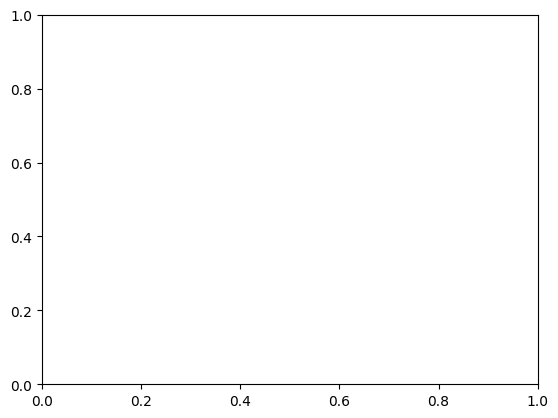

In [87]:
#plot TIM3 exprsesion spatially with scanpy
sc.pl.spatial(
    adata_unified[adata_unified.obs["patient_exp"] == "NUT_9_ROI4"],
    color="CD8",
    spot_size=60,
    cmap="magma",
    img_key=None,
    library_id=None,
    use_raw = False
)

In [19]:
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Compute per-patient neighborhood proportions ---
counts = (
    adata_neighborhoods.obs
    .groupby(["patient_ID", "neighborhood"])
    .size()
    .unstack(fill_value=0)
)

# convert counts to proportions (rows sum to 1)
proportions = counts.div(counts.sum(axis=1), axis=0)

print(proportions.shape)  # (n_patients, n_neighborhoods)
proportions.head()

(13, 12)


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_20537/586789659.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["patient_ID", "neighborhood"])


neighborhood,Epithelial_adjacent,Lymphatic_immune,Lymphoid_B,Lymphoid_T,Lymphoid_enriched,Myeloid_granulocytic,Stromal_NFC,Stromal_fibroblasts,Tumor_NFC,Tumor_bulk,Tumor_myeloid,Vascular/Endothelial
patient_ID,,,,,,,,,,,,
NUT_1,0.000000,0.038918,0.000461,0.002768,0.000797,0.000000,0.200461,0.050577,0.231705,0.266010,0.183141,0.025163
NUT_2,0.018043,0.048797,0.000000,0.004693,0.004146,0.024923,0.188263,0.132267,0.128941,0.144888,0.212639,0.092400
NUT_4,0.000000,0.010151,0.000000,0.008088,0.007098,0.037923,0.219618,0.063467,0.139355,0.262823,0.188545,0.062931
NUT_5,0.079972,0.027827,0.001491,0.008691,0.009674,0.030249,0.203588,0.044257,0.182644,0.217830,0.127200,0.066576
NUT_6,0.060742,0.232249,0.009998,0.040254,0.031600,0.046942,0.018455,0.011998,0.037140,0.283026,0.196978,0.030617


In [20]:
# --- 2. Build an AnnData of patients x neighborhood-proportions ---
# this lets you reuse scanpy's PCA/UMAP/clustering machinery directly
import anndata as ad

adata_patients = ad.AnnData(X=proportions.values)
adata_patients.obs_names = proportions.index.astype(str)
adata_patients.var_names = proportions.columns.astype(str)
adata_patients.obs["patient_ID"] = proportions.index.values

In [21]:
# --- 3. Scale, PCA, neighbors, UMAP ---
sc.pp.scale(adata_patients, zero_center=True)   # standardize proportions across patients
sc.tl.pca(adata_patients, n_comps=min(10, adata_patients.shape[1]-1))
sc.pp.neighbors(adata_patients, n_neighbors=10, use_rep="X_pca")
sc.tl.umap(adata_patients)

/Users/jawadalaaedeen/Desktop/PhD/NMC/NUT_spatial/figures/.pixi/envs/default/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
# --- 4. K-means clustering on the PCA representation ---
n_clusters = 4  # adjust based on your data / elbow method

km = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
adata_patients.obs["kmeans"] = km.fit_predict(adata_patients.obsm["X_pca"]).astype(str)

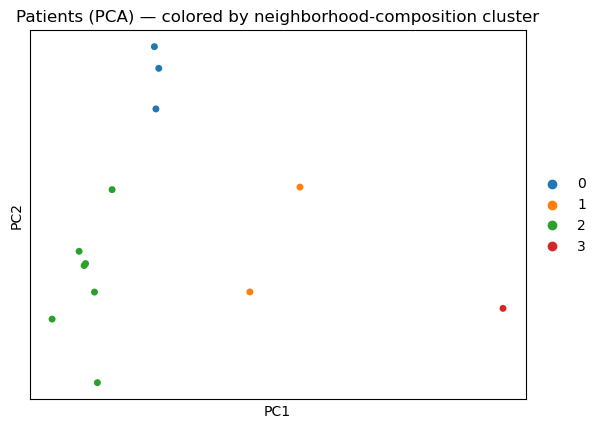

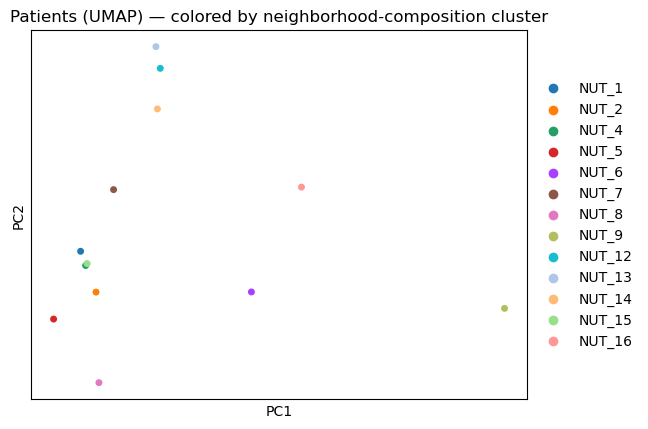

In [31]:
# --- 5. Plot: PCA and UMAP colored by K-means cluster ---
sc.pl.pca(adata_patients, color="kmeans", title="Patients (PCA) — colored by neighborhood-composition cluster", size=100)
sc.pl.pca(adata_patients, color="patient_ID", title="Patients (UMAP) — colored by neighborhood-composition cluster", size = 100)